# IEEE-CIS Fraud Detection - EDA

This notebook performs exploratory data analysis on the IEEE-CIS Fraud Detection dataset downloaded from Kaggle. The labelled dataset has two files, `train_transaction.csv`
and `train_identity.csv`, which are merged using `TransactionID`.

The purpose of this notebook is to examine the dataset structure, class imbalance, missing values, transaction characteristics, categorical feature distributions,
temporal patterns and relationships between numerical features and fraud.

Data preprocessing, feature preparation and machine-learning modelling are performed separately in the preprocessing and modelling notebook.



** Transaction Table **

TransactionDT: timedelta from a given reference datetime (not an actual timestamp)

TransactionAmt: transaction payment amount in USD

ProductCD: product code, the product for each transaction

card1 - card6: payment card information, such as card type, card category, issue bank, country, etc.

addr: address

dist: distance

P_emaildomain and R_emaildomain : purchaser and recipient email domain

C1-C14: counting, such as how many addresses are found to be associated with the payment card, etc. The actual meaning is masked.

D1-D15: timedelta, such as days between previous transaction, etc.

M1-M9: match, such as names on card and address, etc.

Vxxx: Vesta engineered rich features, including ranking, counting, and other entity relations.

Categorical Features: ProductCD card1 - card6 addr1, addr2 P_emaildomain R_emaildomain M1 - M9


** Identity Table **

Variables in this table are identity information – network connection information (IP, ISP, Proxy, etc) and digital signature (UA/browser/os/version, etc) associated with transactions. They're collected by Vesta’s fraud protection system and digital security partners. (The field names are masked and a detailed feature dictionary is not provided for privacy protection.)

Categorical Features: DeviceType DeviceInfo id_12 - id_38

# 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# 2. Load data

In [2]:
data_folder = Path("/Users/lata.bharati/Documents/Dissertation/Fraud Detection/Dataset/IEEE-CIS Fraud Detection")

print("Folder exists:", data_folder.exists())

train_transaction = pd.read_csv(data_folder / "train_transaction.csv")
train_identity = pd.read_csv(data_folder / "train_identity.csv")


print("Transaction data shape:", train_transaction.shape)
print("Identity data shape:", train_identity.shape)


Folder exists: True
Transaction data shape: (590540, 394)
Identity data shape: (144233, 41)


Display columns with datatype and non-null count for both train_transaction and train_identity

In [3]:
train_transaction.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Data columns (total 394 columns):
 #    Column          Non-Null Count   Dtype  
---   ------          --------------   -----  
 0    TransactionID   590540 non-null  int64  
 1    isFraud         590540 non-null  int64  
 2    TransactionDT   590540 non-null  int64  
 3    TransactionAmt  590540 non-null  float64
 4    ProductCD       590540 non-null  object 
 5    card1           590540 non-null  int64  
 6    card2           581607 non-null  float64
 7    card3           588975 non-null  float64
 8    card4           588963 non-null  object 
 9    card5           586281 non-null  float64
 10   card6           588969 non-null  object 
 11   addr1           524834 non-null  float64
 12   addr2           524834 non-null  float64
 13   dist1           238269 non-null  float64
 14   dist2           37627 non-null   float64
 15   P_emaildomain   496084 non-null  object 
 16   R_emaildomain   137291 non-null  obj

In [4]:
pd.set_option('display.max_columns',394)
train_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,T,T,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [5]:
train_identity.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144233 entries, 0 to 144232
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionID  144233 non-null  int64  
 1   id_01          144233 non-null  float64
 2   id_02          140872 non-null  float64
 3   id_03          66324 non-null   float64
 4   id_04          66324 non-null   float64
 5   id_05          136865 non-null  float64
 6   id_06          136865 non-null  float64
 7   id_07          5155 non-null    float64
 8   id_08          5155 non-null    float64
 9   id_09          74926 non-null   float64
 10  id_10          74926 non-null   float64
 11  id_11          140978 non-null  float64
 12  id_12          144233 non-null  object 
 13  id_13          127320 non-null  float64
 14  id_14          80044 non-null   float64
 15  id_15          140985 non-null  object 
 16  id_16          129340 non-null  object 
 17  id_17          139369 non-nul

In [6]:
pd.set_option('display.max_columns', 41)
train_identity.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,NaN,100.0,NotFound,49.0,-300.0,New,NotFound,166.0,NaN,621.0,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,iOS 11.1.2,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,52.0,NaN,Found,Found,121.0,NaN,410.0,142.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,NaN,100.0,NotFound,52.0,NaN,New,NotFound,225.0,NaN,176.0,507.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,NaN,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,0.0,100.0,NotFound,NaN,-300.0,Found,Found,166.0,15.0,529.0,575.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Found,Found,Mac OS X 10_11_6,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


# 3. Merge transaction and identity data 

In [7]:
transaction_df = train_transaction.copy()
identity_df = train_identity.copy()

# Add column to show identity data is available
identity_df["has_identity"] = 1

# Merge transaction and identity data using TransactionID
df = transaction_df.merge(identity_df, on="TransactionID", how="left")

# If identity data is not available replace NaN with 0
df["has_identity"] = df["has_identity"].fillna(0).astype("int8")

print("Transaction data shape:", transaction_df.shape)
print("Identity data shape:", identity_df.shape)
print("Merged data shape:", df.shape)

print("Without identity data:", (df["has_identity"] == 0).sum())
print("With identity data:", (df["has_identity"] == 1).sum())

Transaction data shape: (590540, 394)
Identity data shape: (144233, 42)
Merged data shape: (590540, 435)
Without identity data: 446307
With identity data: 144233


A binary feature, has_identity, was created to indicate whether a matching identity-table record was available for each transaction.
A value of 1 indicates that a matching identity record was present, while 0 indicates that no matching record was available.

In [8]:
pd.set_option('display.max_columns',435)
df.head(10)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,has_identity
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.

In [9]:
# Categorical features based on the dataset description(as per information available on Kaggle)
categorical_features = (
    ["ProductCD"]
    + [f"card{i}" for i in range(1, 7)]
    + ["addr1", "addr2", "P_emaildomain", "R_emaildomain"]
    + [f"M{i}" for i in range(1, 10)]
    + ["DeviceType", "DeviceInfo"]
    + [f"id_{i:02d}" for i in range(12, 39)]
)

categorical_features = [
    col for col in categorical_features
    if col in df.columns
]

# Numerical features
numerical_features = [
    col for col in df.columns
    if col not in categorical_features
    and col not in ["TransactionID", "isFraud"]
]

print("Categorical features:", len(categorical_features))
print(categorical_features)

print("\nNumerical features:", len(numerical_features))
print(numerical_features)

Categorical features: 49
['ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'DeviceType', 'DeviceInfo', 'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']

Numerical features: 384
['TransactionDT', 'TransactionAmt', 'dist1', 'dist2', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V

In [10]:
def get_feature_type(column):

    if column == "TransactionID":
        return "Identifier"

    elif column == "isFraud":
        return "Target"

    elif column in categorical_features:
        return "Categorical"

    else:
        return "Numerical"

feature_type_summary = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Unique Values": df.nunique().values,
    "Feature Type": [
        get_feature_type(col)
        for col in df.columns
    ]
})

display(feature_type_summary)

,Feature,Data Type,Unique Values,Feature Type
0,TransactionID,int64,590540,Identifier
1,isFraud,int64,2,Target
2,TransactionDT,int64,573349,Numerical
3,TransactionAmt,float64,20902,Numerical
4,ProductCD,object,5,Categorical
...,...,...,...,...
430,id_37,object,2,Categorical
431,id_38,object,2,Categorical
432,DeviceType,object,2,Categorical
433,DeviceInfo,object,1786,Categorical


# 4. Missing Values

In [11]:
# Create a table of all columns containing missing values
missing_summary = pd.DataFrame({"Missing Count": df.isnull().sum(),"Missing Percentage": (df.isnull().mean() * 100).round(4)})

# Keeping columns with missing values
missing_summary = missing_summary[missing_summary["Missing Count"] > 0].sort_values(by="Missing Percentage", ascending=False)

# Show every row
with pd.option_context("display.max_rows", None):
    display(missing_summary)

print("Total columns with missing values:", len(missing_summary))

,Missing Count,Missing Percentage
id_24,585793,99.1962
id_25,585408,99.1310
id_07,585385,99.1271
id_08,585385,99.1271
id_21,585381,99.1264
id_26,585377,99.1257
id_27,585371,99.1247
id_23,585371,99.1247
id_22,585371,99.1247
dist2,552913,93.6284


Total columns with missing values: 414


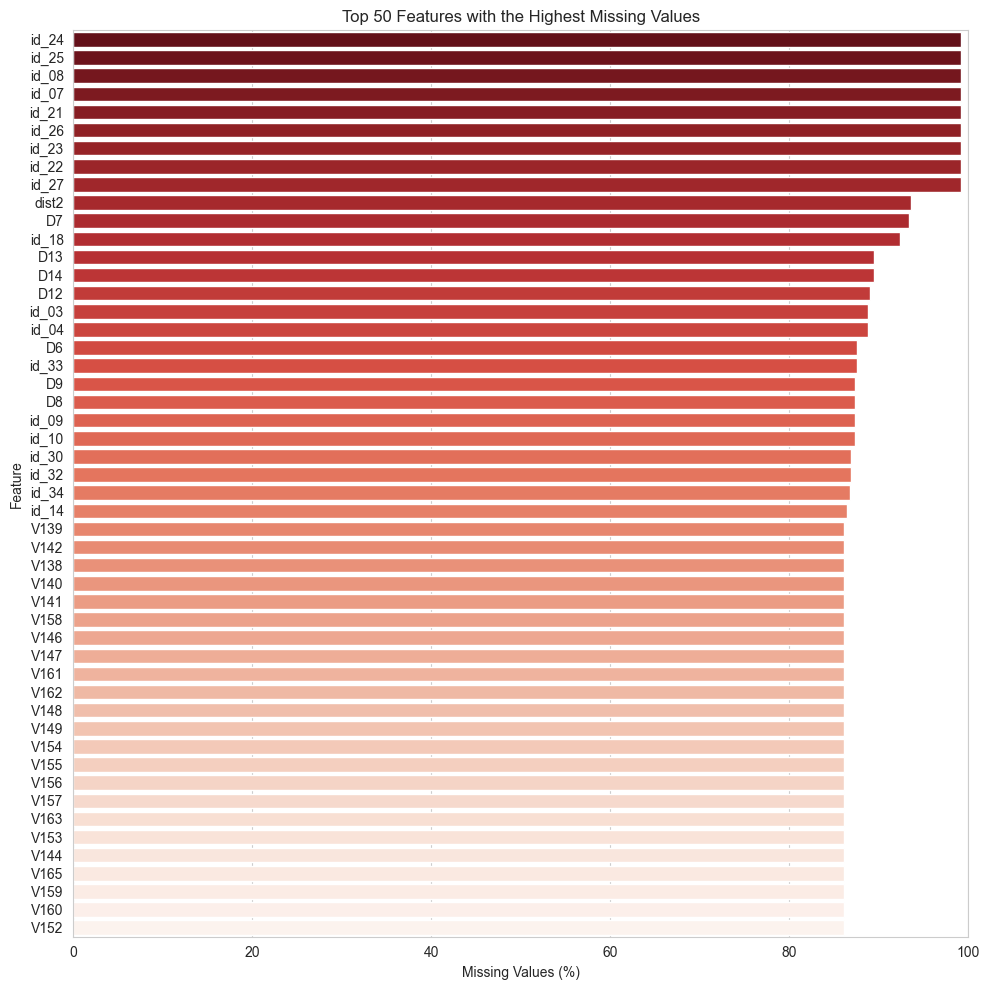

In [12]:
# Calculate missing value percentage
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)

# Select top 50 features with highest missing values
top_missing = missing_percentage.head(50)

palette = sns.color_palette("Reds", n_colors=len(top_missing))[::-1]
plt.figure(figsize=(10, 10))
sns.barplot(x=top_missing.values, y=top_missing.index, palette=palette)
plt.title("Top 50 Features with the Highest Missing Values")
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

In [13]:
fraud_missing_percentage = (df[df["isFraud"] == 1].isnull().mean().mul(100).sort_values(ascending=False))
print(fraud_missing_percentage)

id_24           98.054494
id_25           97.981900
id_26           97.943183
id_23           97.938344
id_21           97.938344
                  ...    
C10              0.000000
C11              0.000000
C12              0.000000
C13              0.000000
has_identity     0.000000
Length: 435, dtype: float64


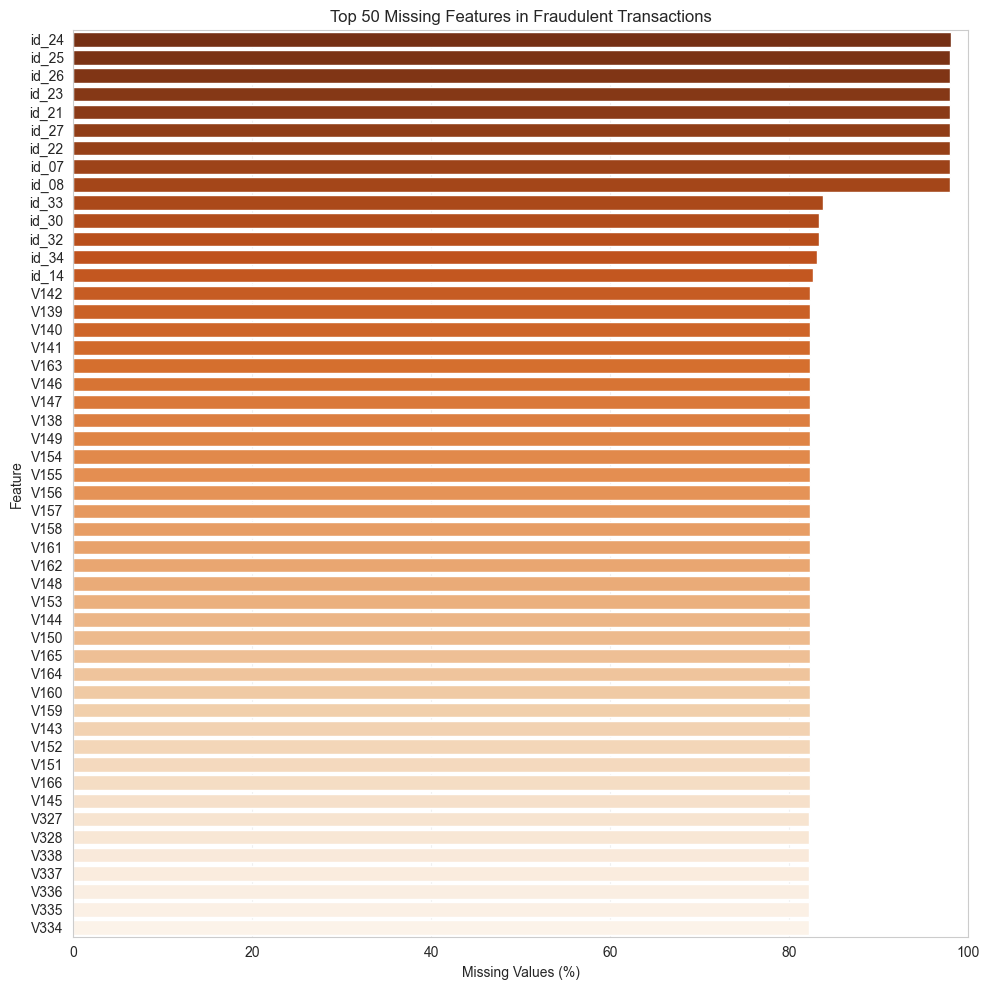

In [14]:
# Top 50 features with highest missing values in fraud transactions
top_fraud_missing = fraud_missing_percentage.head(50)
palette = sns.color_palette("Oranges", n_colors=len(top_fraud_missing))[::-1]

plt.figure(figsize=(10, 10))
ax = sns.barplot(x=top_fraud_missing.values, y=top_fraud_missing.index, palette=palette)
plt.title("Top 50 Missing Features in Fraudulent Transactions")
plt.xlabel("Missing Values (%)")
plt.ylabel("Feature")
plt.xlim(0, 100)
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

The fraud-only missingness analysis was used for descriptive EDA only. No preprocessing decision was based on the fraud-only subset.
Missing-value preprocessing decisions were later learned exclusively from the training data in the modelling notebook.

In [15]:
print("Dataset shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset shape: (590540, 435)
Number of rows: 590540
Number of columns: 435


In [16]:
# Check fraud distribution after merge
print("\nFraud distribution:")
print(df["isFraud"].value_counts())

print("\nFraud percentage:")
print(df["isFraud"].value_counts(normalize=True) * 100)


Fraud distribution:
isFraud
0    569877
1     20663
Name: count, dtype: int64

Fraud percentage:
isFraud
0    96.500999
1     3.499001
Name: proportion, dtype: float64


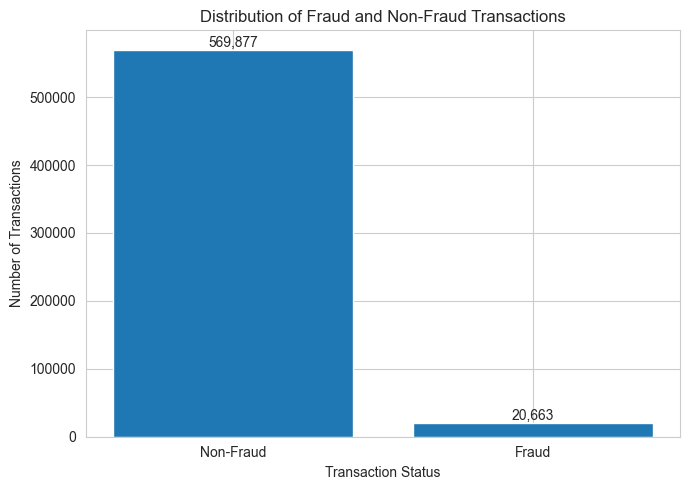

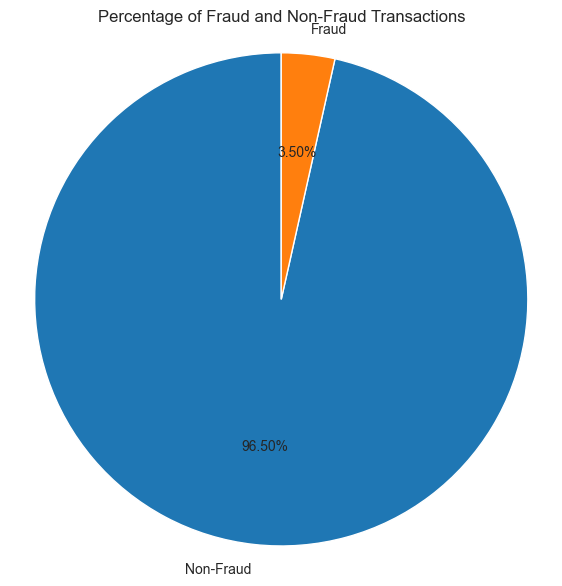

In [17]:
# Count fraud and non-fraud transactions
fraud_counts = df["isFraud"].value_counts().sort_index()

# Change 0 and 1 into readable labels
fraud_counts.index = ["Non-Fraud", "Fraud"]

# Bar chart
plt.figure(figsize=(7, 5))
bars = plt.bar( fraud_counts.index, fraud_counts.values )

plt.title("Distribution of Fraud and Non-Fraud Transactions")
plt.xlabel("Transaction Status")
plt.ylabel("Number of Transactions")
for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{int(bar.get_height()):,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

# Pie chart
plt.figure(figsize=(7, 7))
plt.pie(fraud_counts.values, labels=fraud_counts.index, autopct="%1.2f%%", startangle=90)
plt.title("Percentage of Fraud and Non-Fraud Transactions")
plt.axis("equal")
plt.show()

The target variable is highly imbalanced: approximately 3.5% of transactions are labelled as fraudulent, while approximately 96.5% are non-fraudulent.

# TransactionDT: This is timedelta from a given reference datetime
"TransactionDT" does not contain actual timestamp but it records time (elapsed seconds) from a common reference point. Hence, it preserves the chronological order and relative spacing of transactions but actual calendar dates, weekdays and clock times cannot be recovered. Relative transaction days, weeks and repeating time cycles were therefore used for temporal EDA.

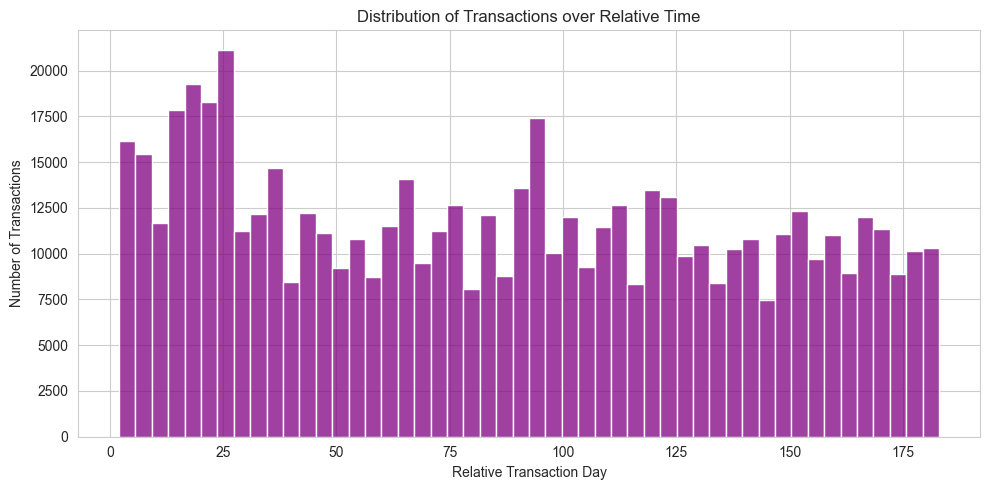

In [18]:
# Convert TransactionDT from seconds into relative days
df["TransactionDay"] = (df["TransactionDT"] // 86400).astype(int) + 1

plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="TransactionDay", bins=50, color="purple")
plt.title("Distribution of Transactions over Relative Time")
plt.xlabel("Relative Transaction Day")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

Transaction activity varied across the relative observation period, with several periods showing higher transaction volumes. As TransactionDT represents elapsed seconds from an undisclosed reference point, it was converted into relative transaction days for easier interpretation.

,fraud_rate,transaction_count
TransactionWeek,,
1,2.805544,23810
2,2.614826,27803
3,2.550044,34470
4,1.852299,37251
5,3.822636,24041
6,3.832083,21868
7,3.859357,20392
8,4.119850,20025
9,4.553986,20246


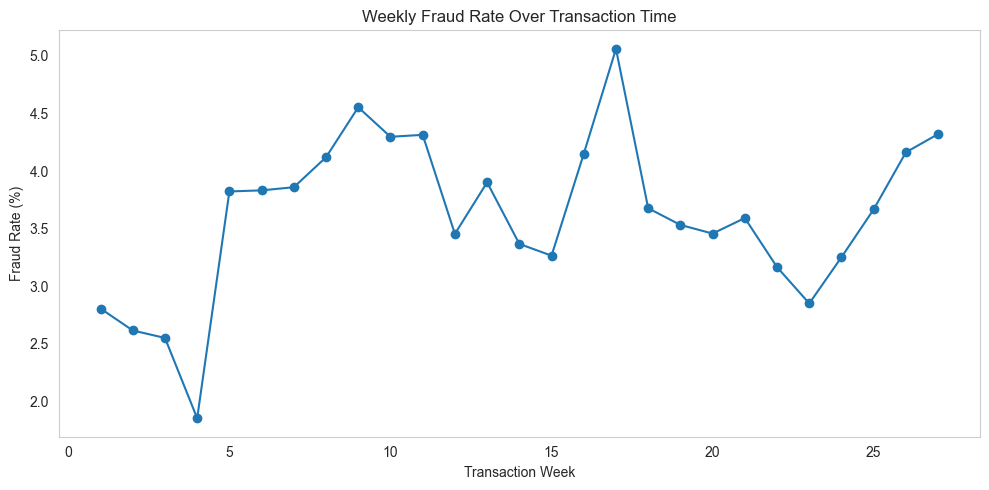

In [19]:
# Create relative transaction week
df["TransactionWeek"] = ((df["TransactionDay"] - 1) // 7).astype(int) + 1

# Calculate weekly transaction count and fraud rate
weekly_summary = (df.groupby("TransactionWeek")["isFraud"].agg(fraud_rate="mean",transaction_count="count"))

# Convert fraud rate into percentage
weekly_summary["fraud_rate"] *= 100

display(weekly_summary)

# Plot weekly fraud rate
plt.figure(figsize=(10, 5))
plt.plot(weekly_summary.index, weekly_summary["fraud_rate"], marker="o")
plt.title("Weekly Fraud Rate Over Transaction Time")
plt.xlabel("Transaction Week")
plt.ylabel("Fraud Rate (%)")
plt.grid(False)
plt.tight_layout()
plt.show()

,RelativeWeekday,Number of Transactions,Fraud Percentage
0,0,86377,3.717425
1,1,98502,3.603988
2,2,79834,3.711451
3,3,70223,3.564359
4,4,85433,3.145155
5,5,84815,3.304840
6,6,85356,3.451427


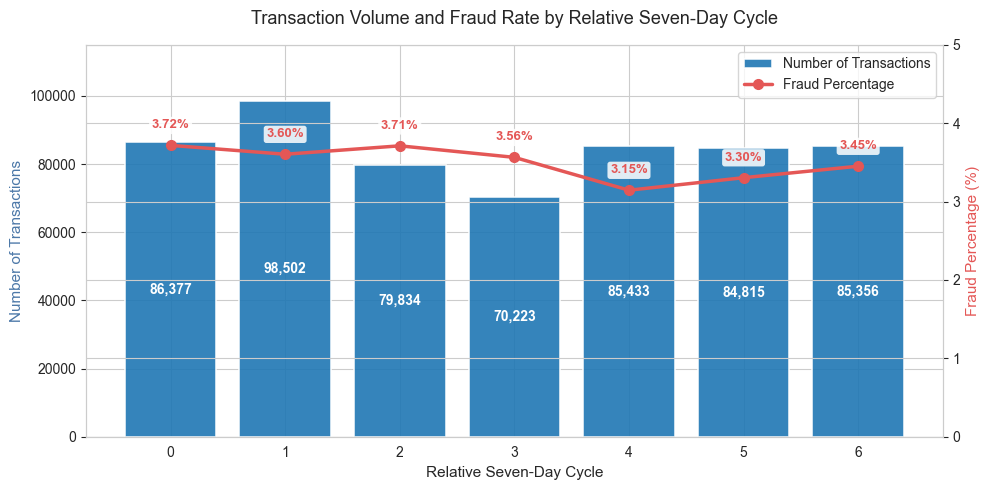

In [20]:
# Feature Engineering: Relative weekday (0-6)
df["RelativeWeekday"] = (df["TransactionDT"] // 86400) % 7

# Calculate count and fraud rate together
tmp = (df.groupby("RelativeWeekday").agg(**{"Number of Transactions": ("TransactionID", "count"), "Fraud Percentage": ("isFraud", lambda x: x.mean() * 100),}).reset_index())

display(tmp)

fig, ax1 = plt.subplots(figsize=(10, 5))
# Primary Axis: Bars for Transaction Counts
bars = ax1.bar(tmp["RelativeWeekday"], tmp["Number of Transactions"],edgecolor="white", linewidth=1.2, alpha=0.9,label="Number of Transactions")
ax1.set_xlabel("Relative Seven-Day Cycle", fontsize=11)
ax1.set_ylabel("Number of Transactions", color="#4C78A8", fontsize=11)
ax1.set_xticks(range(7))
ax1.set_ylim(0, 115000)
ax1.bar_label(bars, fmt="{:,.0f}", label_type="center", fontsize=10, color="white", fontweight="bold")

# Secondary Axis: Line for Fraud Percentage
ax2 = ax1.twinx()
ax2.plot(tmp["RelativeWeekday"], tmp["Fraud Percentage"], color="#E45756", marker="o", markersize=7, linewidth=2.5, label="Fraud Percentage")
ax2.set_ylabel("Fraud Percentage (%)", color="#E45756", fontsize=11)
ax2.set_ylim(0, 5)

# Annotate red percentages cleanly above the line markers
for x, y in zip(tmp["RelativeWeekday"], tmp["Fraud Percentage"]):
    ax2.annotate(f"{y:.2f}%", xy=(x, y), xytext=(0, 10), textcoords="offset points", ha="center", va="bottom", fontsize=9.5, color="#E45756", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.85,))

# Combine legends from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper right")
plt.title("Transaction Volume and Fraud Rate by Relative Seven-Day Cycle", fontsize=13, pad=15)
plt.tight_layout()
plt.show()

The number of transactions was different across the seven relative time groups, ranging from around 70,000 to 98,500. The fraud percentage did not change very much and stayed between about 3.15% and 3.72%. Groups 0 and 2 had the highest fraud rates, while group 4 had the lowest. These groups are only based on a repeating seven-day cycle from an unknown starting point, so they cannot be treated as actual weekdays such as Monday or Tuesday.

,RelativeHour,Number_of_Transactions,Fraud_Percentage
0,0,37795,3.137981
1,1,32797,3.131384
2,2,26732,3.748317
3,3,20802,3.831362
4,4,14839,5.189029
5,5,9701,7.030203
6,6,6007,7.774263
7,7,3704,10.610151
8,8,2591,9.301428
9,9,2479,8.995563


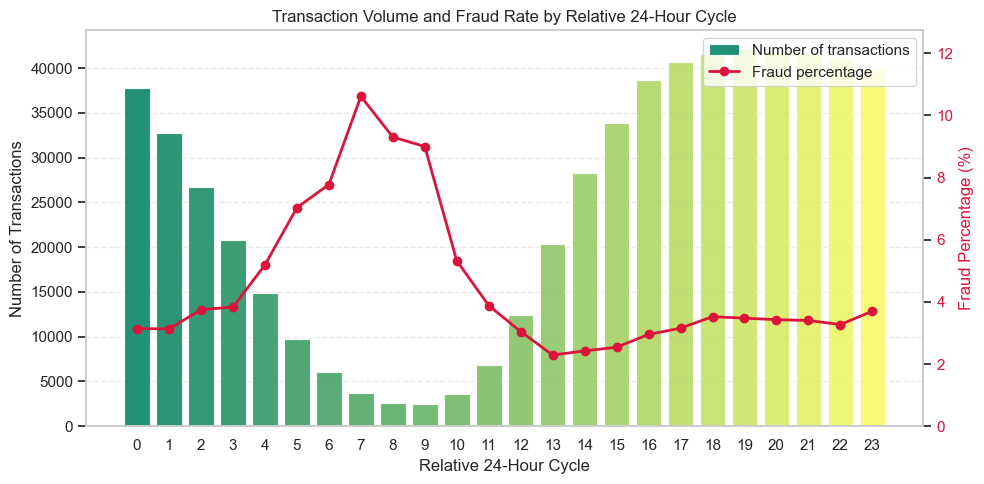

In [21]:
# Creating 24 repeating hourly groups(These are relative hourly groups, not actual clock hours)
df["RelativeHour"] = ((df["TransactionDT"] // 3600) % 24).astype(int)

# Calculate fraud percentage for each relative hour
hourly_summary = (df.groupby("RelativeHour").agg(Number_of_Transactions=("TransactionID", "count"), Fraud_Percentage=("isFraud", "mean")).reset_index())

# Convert fraud proportion into percentage
hourly_summary["Fraud_Percentage"] *= 100
display(hourly_summary)

sns.set_theme(style="whitegrid")
summer_colors = sns.color_palette("summer",n_colors=len(hourly_summary))

fig, ax1 = plt.subplots(figsize=(10, 5))
# Bar chart for transaction count
bars = ax1.bar(hourly_summary["RelativeHour"], hourly_summary["Number_of_Transactions"], color=summer_colors, alpha=0.9,linewidth=0.8, label="Number of transactions")

ax1.set_xlabel("Relative 24-Hour Cycle")
ax1.set_ylabel("Number of Transactions")
ax1.set_xticks(range(24))

# Fraud percentage on second axis
ax2 = ax1.twinx()
ax2.plot(hourly_summary["RelativeHour"], hourly_summary["Fraud_Percentage"], color="crimson", marker="o", linewidth=2, label="Fraud percentage")
ax2.set_ylabel("Fraud Percentage (%)", color="crimson")
ax2.tick_params(axis="y", labelcolor="crimson")
ax2.set_ylim(0, hourly_summary["Fraud_Percentage"].max() * 1.2)
plt.title( "Transaction Volume and Fraud Rate by Relative 24-Hour Cycle")
ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax1.grid(axis="x", visible=False)
ax2.grid(False)
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2,labels1 + labels2,loc="upper right")
plt.tight_layout()
plt.show()


Transaction volume changed considerably across the 24 relative hourly groups. The lowest number of transactions occurred around groups 7 to 10, while the highest transaction volumes were recorded around groups 18 to 22. The fraud rate was highest around groups 7 to 9 and lowest around groups 13 to 15. These groups are based on an unknown reference time, so they cannot be interpreted as actual clock hours.

# TransactionAmt: This is the amount associated with each transaction. 

TransactionAmt contains no missing values.

In [22]:
df['TransactionAmt'].isnull().sum()

np.int64(0)

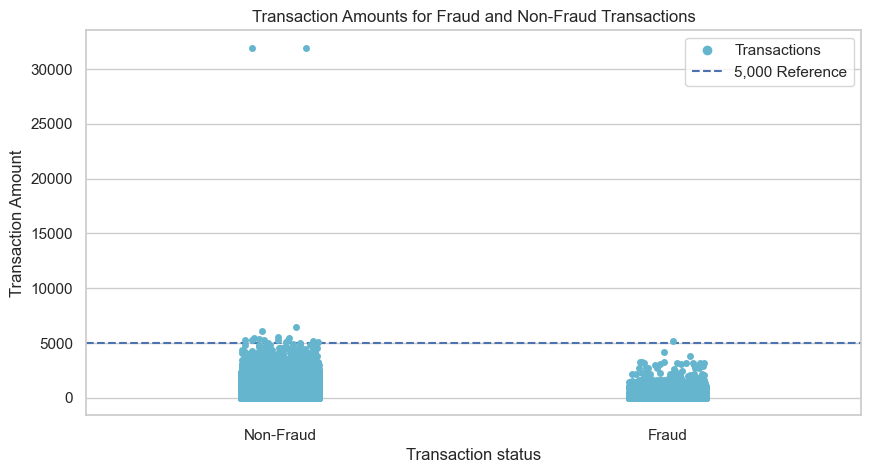

In [23]:
import matplotlib.lines as mlines

plt.figure(figsize=(10,5))
plt.subplot(111)
sns.stripplot(y='TransactionAmt', x='isFraud', data=df, color = 'c')
plt.axhline(5000, color='b', linestyle="--", label="5,000 Reference")
points_handle = mlines.Line2D([], [], color="c", marker="o", linestyle="None", markersize=6, label="Transactions")
plt.xticks([0, 1], ["Non-Fraud", "Fraud"])
plt.title('Transaction Amounts for Fraud and Non-Fraud Transactions')
plt.ylabel("Transaction Amount")
plt.xlabel("Transaction status")
plt.legend(handles=[points_handle, plt.gca().get_legend_handles_labels()[0][0]], loc="upper right")
plt.show()

Most fraud and non-fraud transactions had amounts below 5,000. A small number of non-fraud transactions had much higher amounts, including two transactions above 30,000. Fraudulent transactions generally had lower amounts, with most remaining below 4,000 and only a small number reaching around 5,000. This shows that the transaction amount distribution contains some extreme outliers, especially among non-fraud transactions.

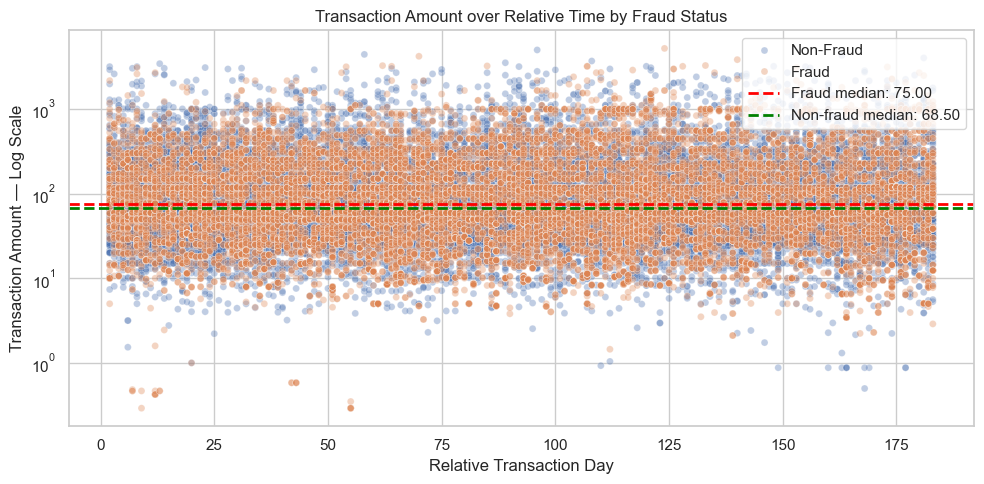

In [24]:
# Create readable fraud labels
df["Fraud Status"] = df["isFraud"].map({0: "Non-Fraud", 1: "Fraud"})

# Select fraud transactions and non-fraud transactions
fraud_data = df[df["isFraud"] == 1]
non_fraud_data = df[df["isFraud"] == 0].sample(n=min(30000, (df["isFraud"] == 0).sum()), random_state=42)

plot_data = pd.concat([non_fraud_data, fraud_data], ignore_index=True)
fraud_median = df.loc[df["isFraud"] == 1, "TransactionAmt"].median()
non_fraud_median = df.loc[df["isFraud"] == 0, "TransactionAmt"].median()

plt.figure(figsize=(10, 5))
sns.scatterplot(data=plot_data, x="TransactionDay", y="TransactionAmt", hue="Fraud Status", alpha=0.35, s=25)
plt.axhline(fraud_median, color="red", linestyle="--", linewidth=2, label=f"Fraud median: {fraud_median:.2f}")
plt.axhline(non_fraud_median, color="green", linestyle="--", linewidth=2, label=f"Non-fraud median: {non_fraud_median:.2f}")
plt.yscale("log")
plt.title("Transaction Amount over Relative Time by Fraud Status")
plt.xlabel("Relative Transaction Day")
plt.ylabel("Transaction Amount — Log Scale")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

Transaction amounts were spread across the full relative observation period for both fraud and non-fraud transactions. Most transactions had relatively low amounts, while a small number of transactions had very high values. Fraud and non-fraud transactions also showed considerable overlap, meaning that transaction amount alone may not be enough to separate the two classes. A logarithmic scale was used because the transaction amounts were highly skewed and contained extreme values.

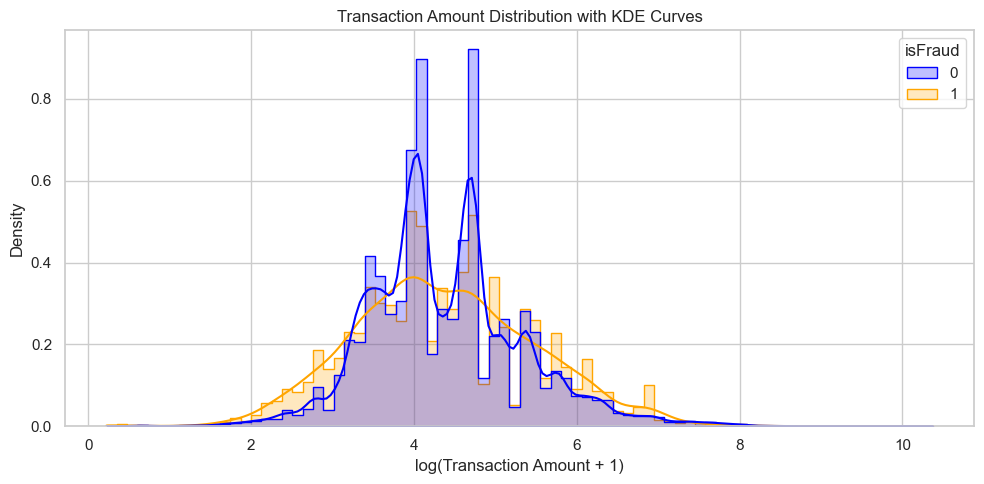

In [25]:
# Transaction amount distribution using log transformation
plot_df = df.copy()
plot_df["LogTransactionAmt"] = np.log1p(plot_df["TransactionAmt"])

plt.figure(figsize=(10, 5))
sns.histplot(data=plot_df, x="LogTransactionAmt", hue="isFraud", stat="density", common_norm=False, bins=80, kde=True, kde_kws={"bw_adjust": 1.5},  element="step", palette={0: "blue", 1: "orange"})
plt.title("Transaction Amount Distribution with KDE Curves")
plt.xlabel("log(Transaction Amount + 1)")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

The transaction amount distribution is highly skewed, so a log transformation was applied for visualisation. Since legitimate transactions greatly outnumber fraudulent transactions, density was used instead of raw frequency. This makes it easier to compare the shape of the transaction amount distribution between fraud and legitimate classes.

# ProductCD: Product Code Associated with Each Transaction



In [26]:
df['ProductCD'].isnull().sum()

np.int64(0)

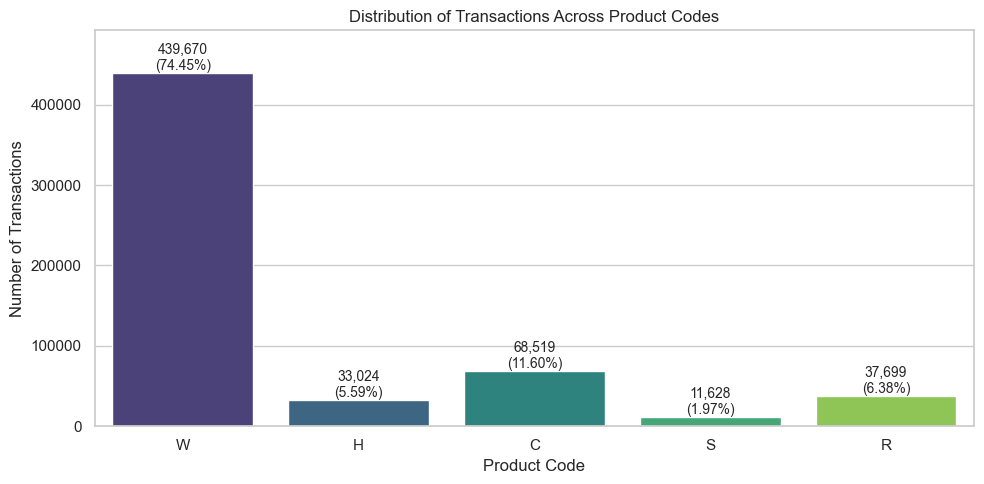

In [27]:
fig, axes = plt.subplots(figsize=(10, 5))
sns.countplot(data=df, x="ProductCD", hue="ProductCD", palette="viridis", legend=False, ax=axes)
axes.set_title("Distribution of Transactions Across Product Codes")
axes.set_xlabel("Product Code")
axes.set_ylabel("Number of Transactions")

# Total number of transactions with a ProductCD value
total_transactions = df["ProductCD"].notna().sum()
# Add count and percentage above each bar
for bar in axes.patches:
    count = int(bar.get_height())
    percentage = count / total_transactions * 100
    axes.text(bar.get_x() + bar.get_width() / 2, count, f"{count:,}\n({percentage:.2f}%)", ha="center", va="bottom", fontsize=10)
axes.set_ylim(0, max(bar.get_height() for bar in axes.patches) * 1.12)

plt.tight_layout()
plt.show()

The distribution of transactions was not equal across the five product-code categories. Product code W had the highest number of transactions and represented most of the dataset. Product code C had the second-highest count, while R and H had much smaller numbers of transactions. Product code S had the lowest number of transactions. This shows that the ProductCD feature is highly imbalanced, with category W dominating the dataset.

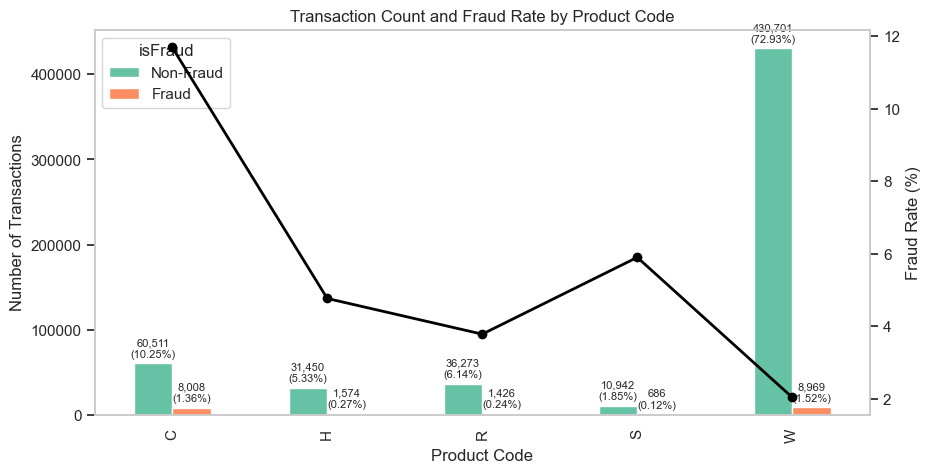

In [28]:
# Count legitimate and fraud transactions for each ProductCD
product_summary = pd.crosstab(df["ProductCD"], df["isFraud"]).rename(columns={0: "Non-Fraud", 1: "Fraud"})

# Fraud rate for each ProductCD
fraud_rate = (product_summary["Fraud"] / product_summary.sum(axis=1) * 100)

# Bar chart
ax = product_summary.plot(kind="bar", figsize=(10, 5), color=sns.color_palette("Set2", 2))

# Add count and percentage to bars
total = product_summary.to_numpy().sum()

for container in ax.containers:
    labels = [
        f"{int(value):,}\n({value / total * 100:.2f}%)"
        for value in container.datavalues
    ]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

# Fraud-rate line
ax2 = ax.twinx()
ax2.plot(range(len(fraud_rate)), fraud_rate.values, color="black", marker="o", linewidth=2, label="Fraud rate")
ax.set_title("Transaction Count and Fraud Rate by Product Code")
ax.set_xlabel("Product Code")
ax.set_ylabel("Number of Transactions")
ax2.set_ylabel("Fraud Rate (%)")
ax.grid(False)
ax2.grid(False)

plt.show()

Product code W had the highest number of transactions and represented most of the dataset. However, it had the lowest fraud rate at approximately 2.04%. Product code C had the highest fraud rate at approximately 11.69%, followed by S at 5.90% and H at 4.77%. This shows that a product code with a high transaction volume does not necessarily have a high fraud rate.

# Card 1-6

All six card variables were retained as categorical features. Visual analysis was focused on card4 and card6 because they contain a small number of directly interpretable categories, whereas the remaining card variables contain substantially more coded values.

In [29]:
cards = [col for col in df.columns if 'card' in col]
df[cards].head()

,card1,card2,card3,card4,card5,card6
0,13926,NaN,150.0,discover,142.0,credit
1,2755,404.0,150.0,mastercard,102.0,credit
2,4663,490.0,150.0,visa,166.0,debit
3,18132,567.0,150.0,mastercard,117.0,debit
4,4497,514.0,150.0,mastercard,102.0,credit


In [30]:
card_features = ["card1", "card2", "card3", "card4", "card5", "card6"]

card_missing = pd.DataFrame({
    "Missing Count": df[card_features].isnull().sum(),
    "Missing Percentage": (
        df[card_features].isnull().mean() * 100
    ).round(4)
})

display(card_missing)

,Missing Count,Missing Percentage
card1,0,0.0000
card2,8933,1.5127
card3,1565,0.2650
card4,1577,0.2670
card5,4259,0.7212
card6,1571,0.2660


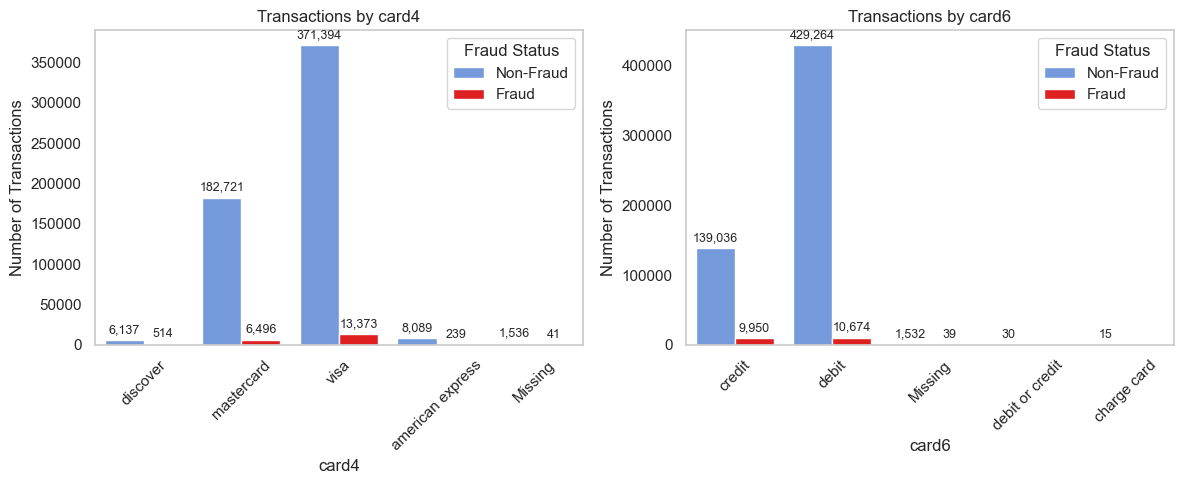

In [31]:
card_features = ["card4", "card6"]

# Replace missing values only in card4 and card6
df[card_features] = (df[card_features].astype("string").fillna("Missing"))
colors = {"Non-Fraud": "cornflowerblue", "Fraud": "red"}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for feature, ax in zip(card_features, axes):
    sns.countplot(data=df, x=feature, hue="Fraud Status", palette=colors, ax=ax)
    for container in ax.containers:
        labels = [
            f"{int(value):,}" if value > 0 else ""
            for value in container.datavalues
        ]
        ax.bar_label(container, labels=labels, padding=3, fontsize=9)
    ax.set_title(f"Transactions by {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Number of Transactions")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(False)
plt.tight_layout()
plt.show()

The distribution of transactions differed across the card4 and card6 categories. For card4, Visa had the highest number of transactions, followed by Mastercard, while Discover and American Express were much less common. For card6, most transactions were made using debit cards, followed by credit cards. Fraudulent transactions were much fewer than non-fraudulent transactions in every category, showing the strong class imbalance in the dataset. The newly created Missing category contained only a small number of transactions.

# P_emailDomain and R_emailDomain

Email domains of the purchaser and recipient.

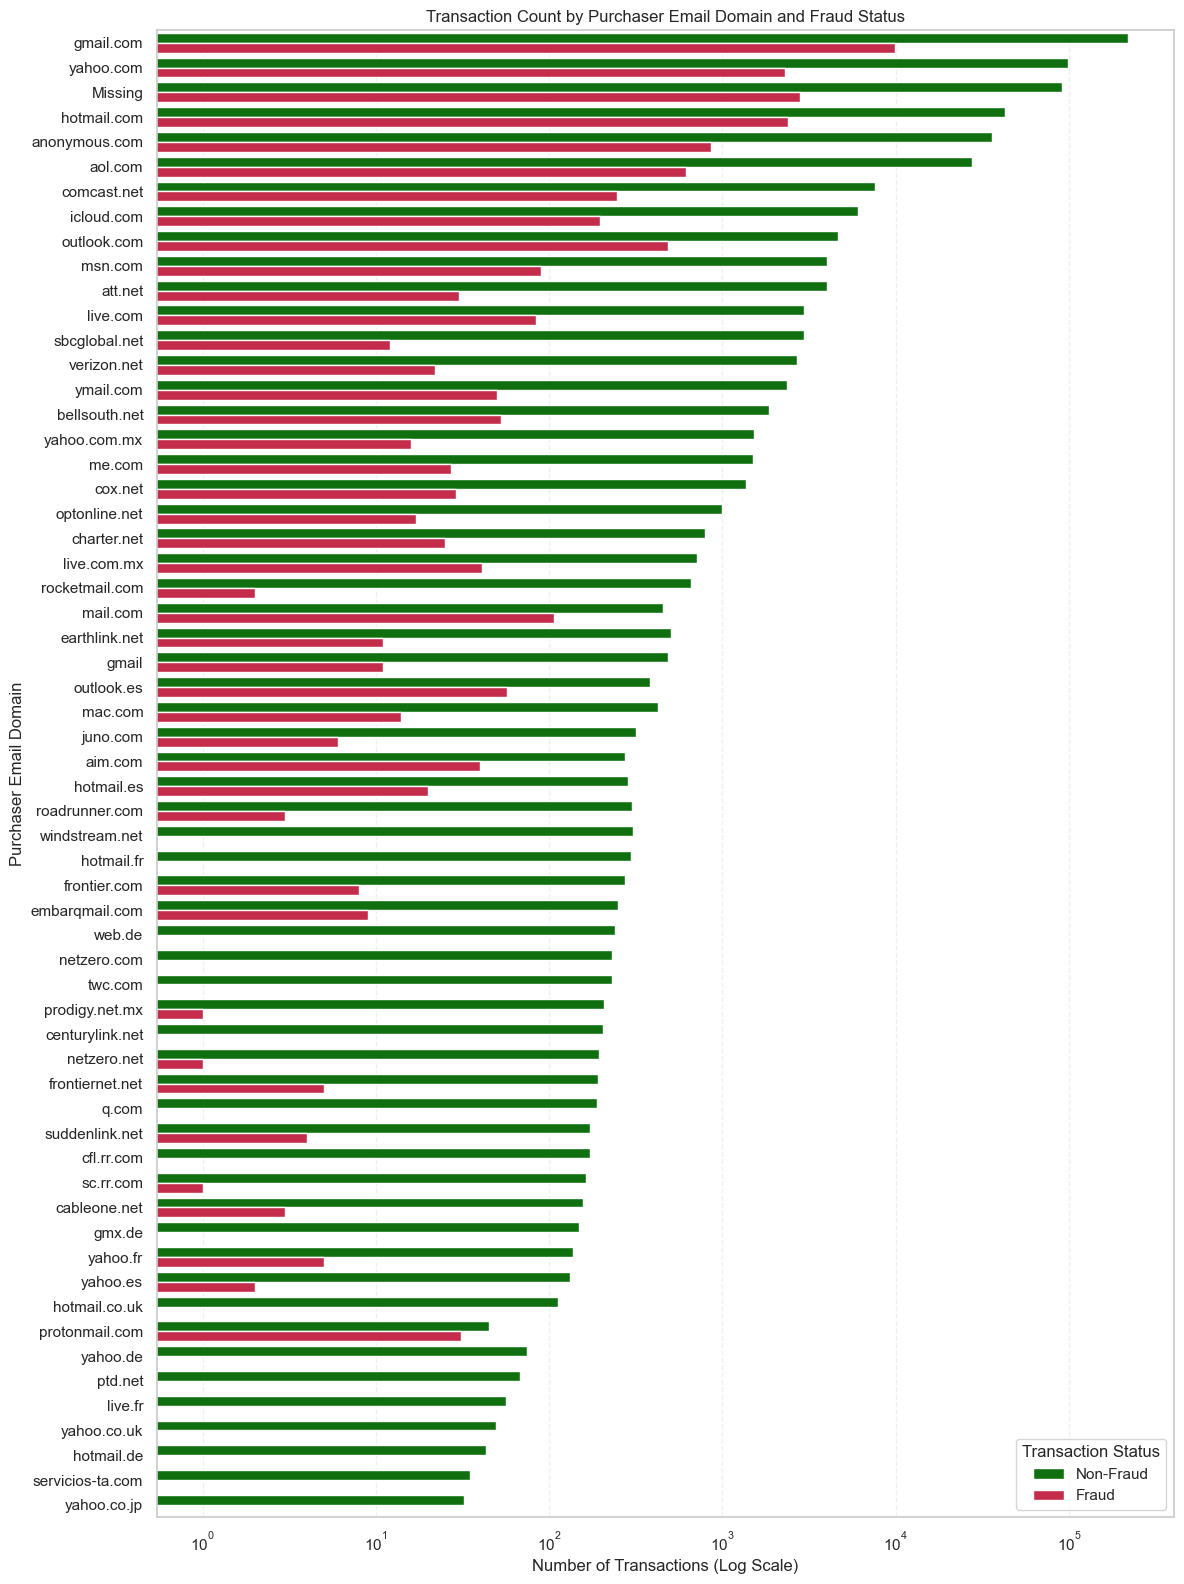

In [32]:
email_data = df.copy()

# Fill missing email domains
email_data["P_emaildomain"] = (email_data["P_emaildomain"].fillna("Missing"))
email_data["Fraud Status"] = (email_data["isFraud"].map({0: "Non-Fraud", 1: "Fraud"}))

# Purchaser email domains by total transactions
P_email_order = (email_data["P_emaildomain"].value_counts().index)

plt.figure(figsize=(12, 16))
sns.countplot(data=email_data, y="P_emaildomain", hue="Fraud Status", order=P_email_order, palette={"Non-Fraud": "green", "Fraud": "crimson"})
plt.title("Transaction Count by Purchaser Email Domain and Fraud Status",)
plt.xlabel("Number of Transactions (Log Scale)")
plt.xscale("log")
plt.ylabel("Purchaser Email Domain")
plt.legend(title="Transaction Status")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

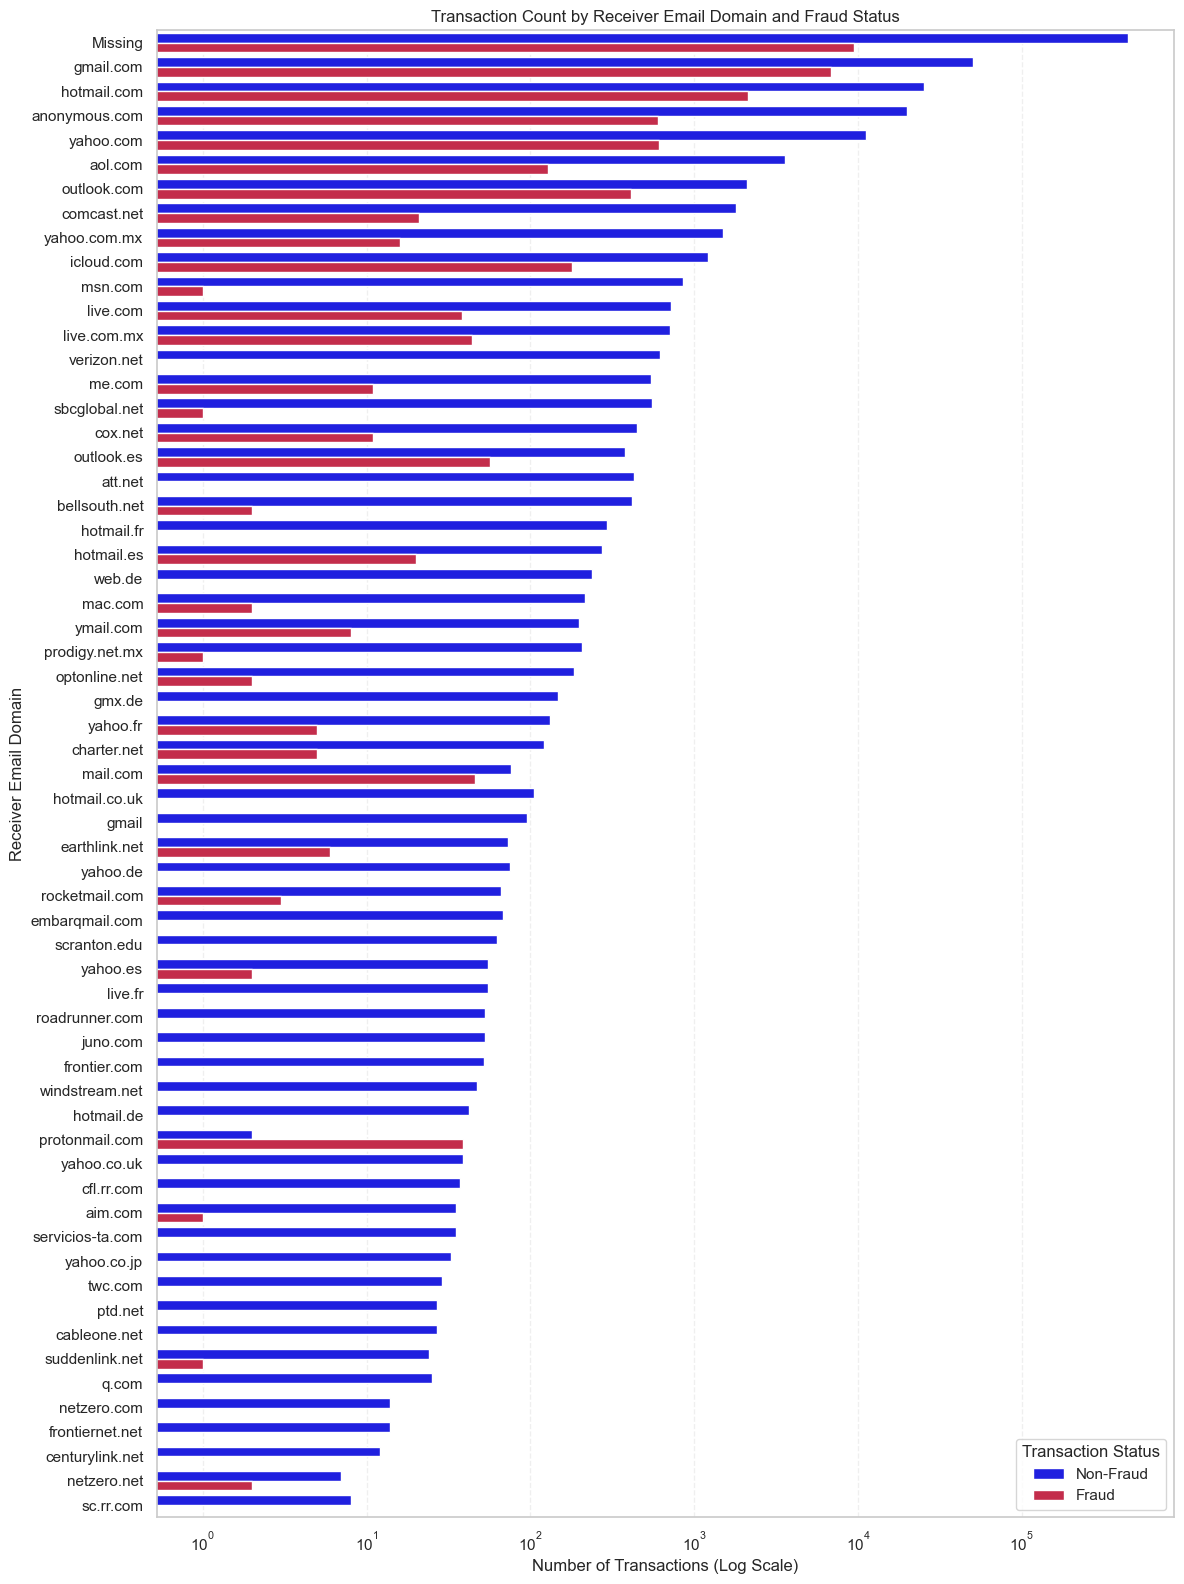

In [33]:
# Fill missing email domains
email_data["R_emaildomain"] = (email_data["R_emaildomain"].fillna("Missing"))

# Receiver email domains by total transactions
R_email_order = (email_data["R_emaildomain"].value_counts().index)

plt.figure(figsize=(12, 16))
sns.countplot(data=email_data, y="R_emaildomain", hue="Fraud Status", order=R_email_order, palette={"Non-Fraud": "blue", "Fraud": "crimson"})
plt.title("Transaction Count by Receiver Email Domain and Fraud Status")
plt.xlabel("Number of Transactions (Log Scale)")
plt.xscale("log")
plt.ylabel("Receiver Email Domain")
plt.legend(title="Transaction Status")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

,Transaction_Count,Fraud_Rate
P_emaildomain,,
hotmail.de,43,0.000000
hotmail.co.uk,112,0.000000
yahoo.co.jp,32,0.000000
windstream.net,305,0.000000
hotmail.fr,295,0.000000
web.de,240,0.000000
yahoo.de,74,0.000000
gmx.de,149,0.000000
cfl.rr.com,172,0.000000


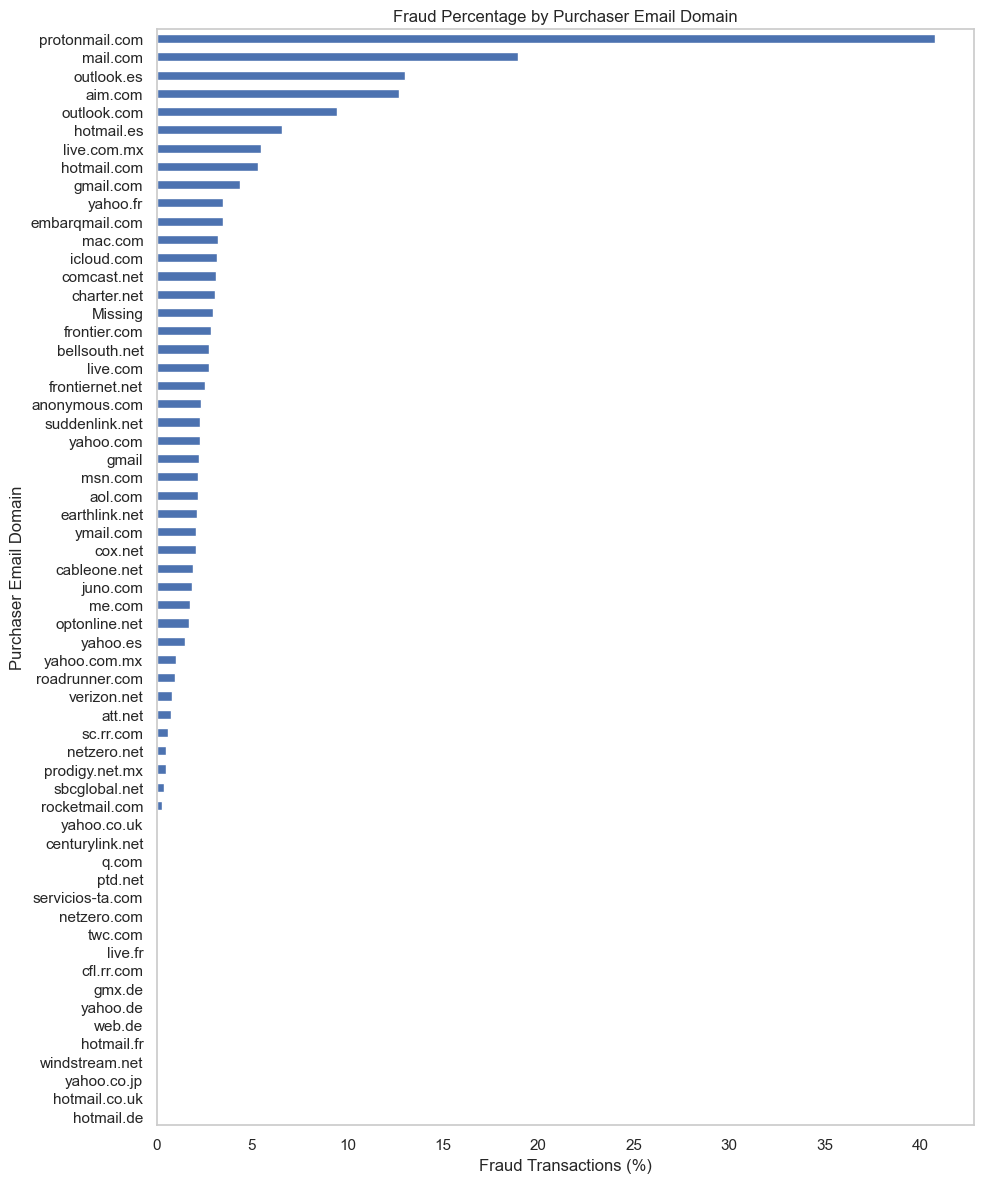

In [34]:
# Purchaser email domain analysis
p_email_summary = (email_data.groupby("P_emaildomain")["isFraud"].agg(Transaction_Count="count",Fraud_Rate="mean"))
p_email_summary["Fraud_Rate"] *= 100

p_email_summary = p_email_summary.sort_values("Fraud_Rate")
display(p_email_summary)

plt.figure(figsize=(10, 12))
ax = p_email_summary["Fraud_Rate"].plot(kind="barh")
ax.set_title("Fraud Percentage by Purchaser Email Domain")
ax.set_xlabel("Fraud Transactions (%)")
ax.set_ylabel("Purchaser Email Domain")
ax.grid(False)
plt.tight_layout()
plt.show()

,Transaction_Count,Fraud_Rate
R_emaildomain,,
hotmail.de,42,0.000000
web.de,237,0.000000
juno.com,53,0.000000
windstream.net,47,0.000000
hotmail.fr,293,0.000000
...,...,...
outlook.es,433,13.163972
outlook.com,2507,16.513761
netzero.net,9,22.222222


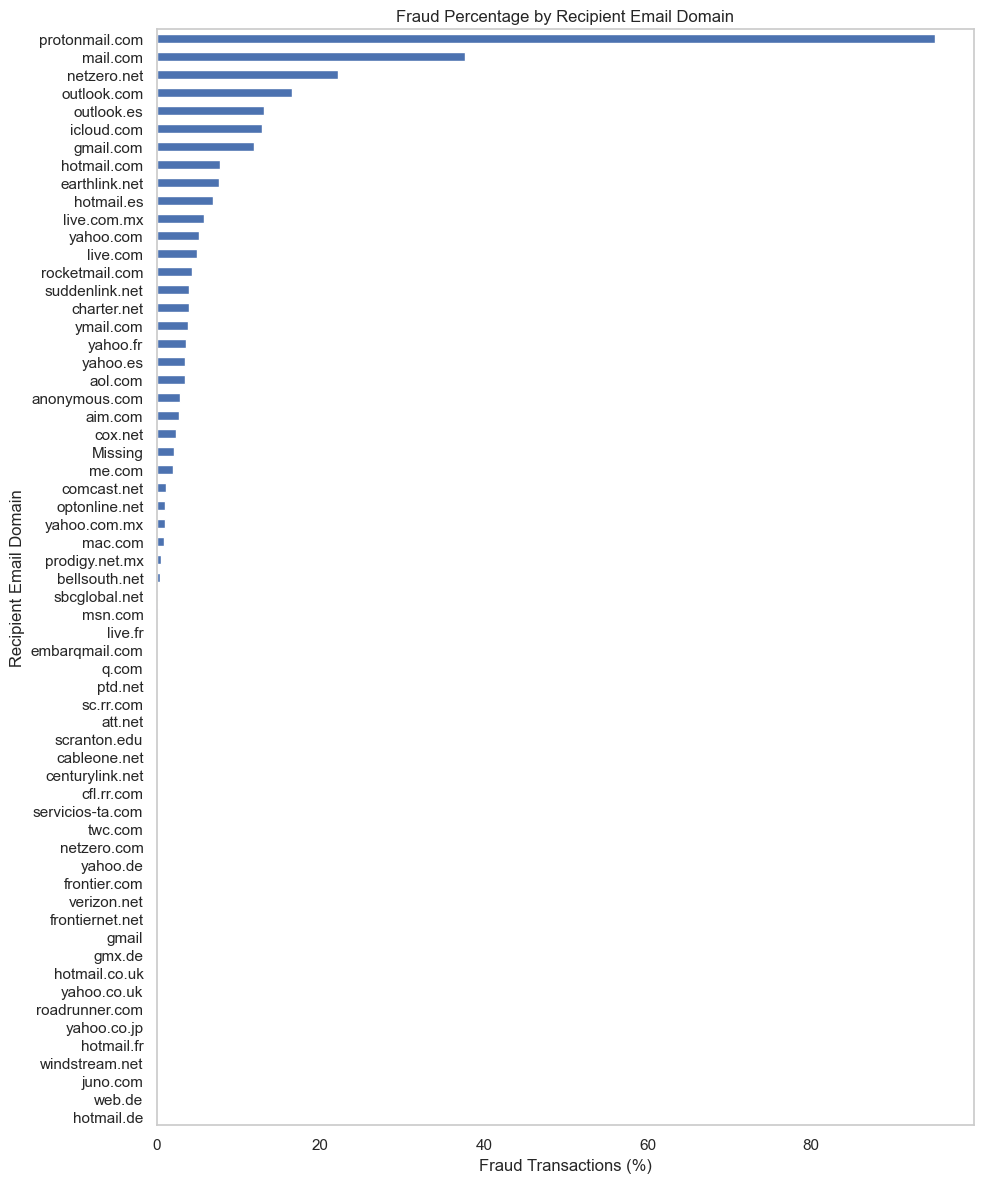

In [35]:
# Recipient email domain analysis
r_email_summary = (email_data.groupby("R_emaildomain")["isFraud"].agg(Transaction_Count="count", Fraud_Rate="mean"))
r_email_summary["Fraud_Rate"] *= 100

r_email_summary = r_email_summary.sort_values("Fraud_Rate")
display(r_email_summary)

plt.figure(figsize=(10, 12))
ax = r_email_summary["Fraud_Rate"].plot(kind="barh")
ax.set_title("Fraud Percentage by Recipient Email Domain")
ax.set_xlabel("Fraud Transactions (%)")
ax.set_ylabel("Recipient Email Domain")
ax.grid(False)
plt.tight_layout()
plt.show()

Fraud rates varied across purchaser and recipient email domains. ProtonMail showed the highest observed fraud percentage in both analyses. However, ProtonMail occurred in relatively few transactions, so these high percentages should be interpreted cautiously.

Common domains such as Gmail, Yahoo and Hotmail had substantially larger sample sizes and generally lower observed fraud rates. Overall, email-domain information may provide useful predictive information, although fraud-rate estimates for rare domains are less stable.

# Addr1, Addr2: Categorical data giving address information

In [36]:
print(df[["addr1", "addr2"]].isnull().sum())

addr1    65706
addr2    65706
dtype: int64


In [37]:
df[["addr1", "addr2"]] = (df[["addr1", "addr2"]].astype("string").fillna("Missing"))

In [38]:
print(df[["addr1", "addr2"]].isnull().sum())

addr1    0
addr2    0
dtype: int64


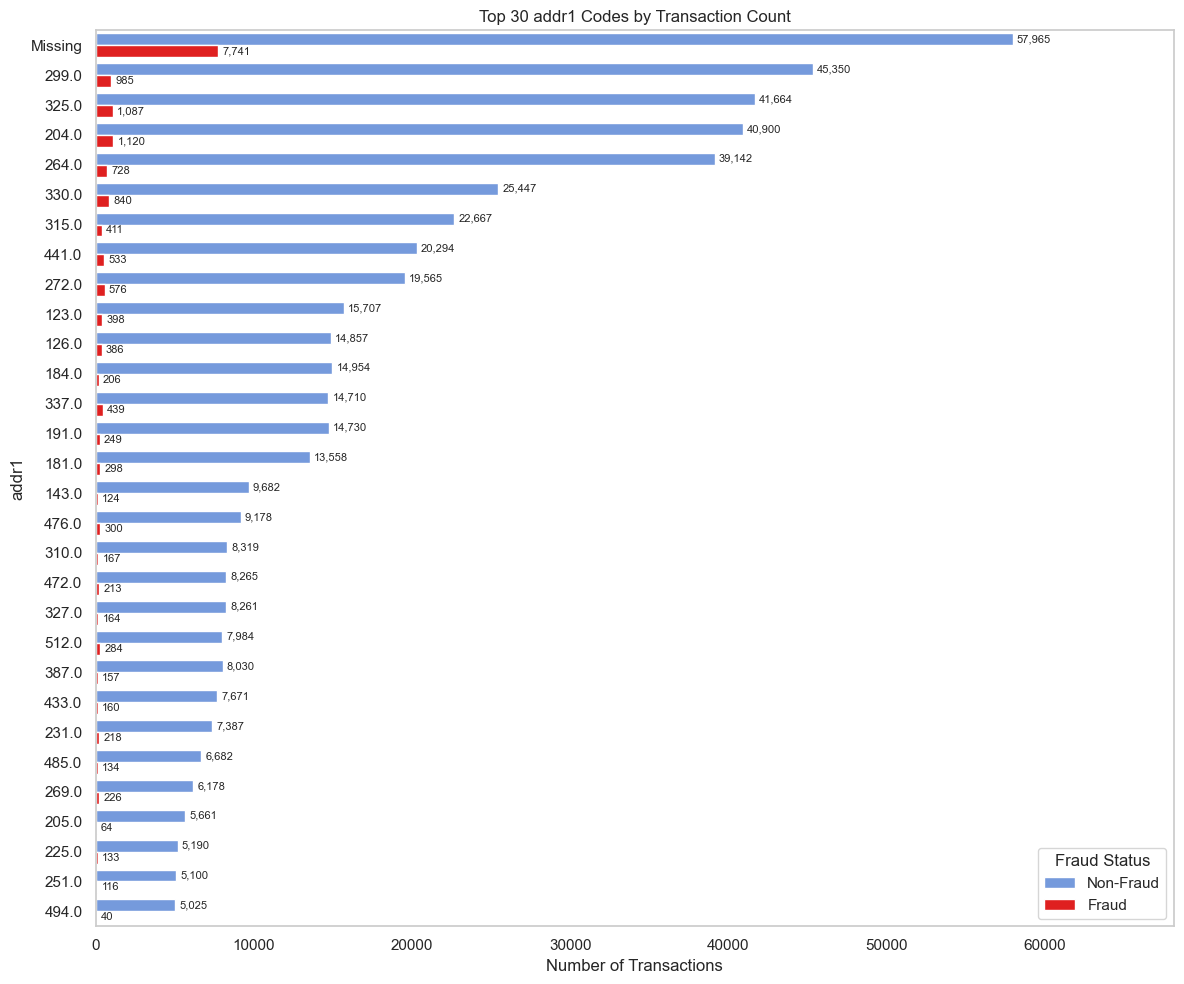

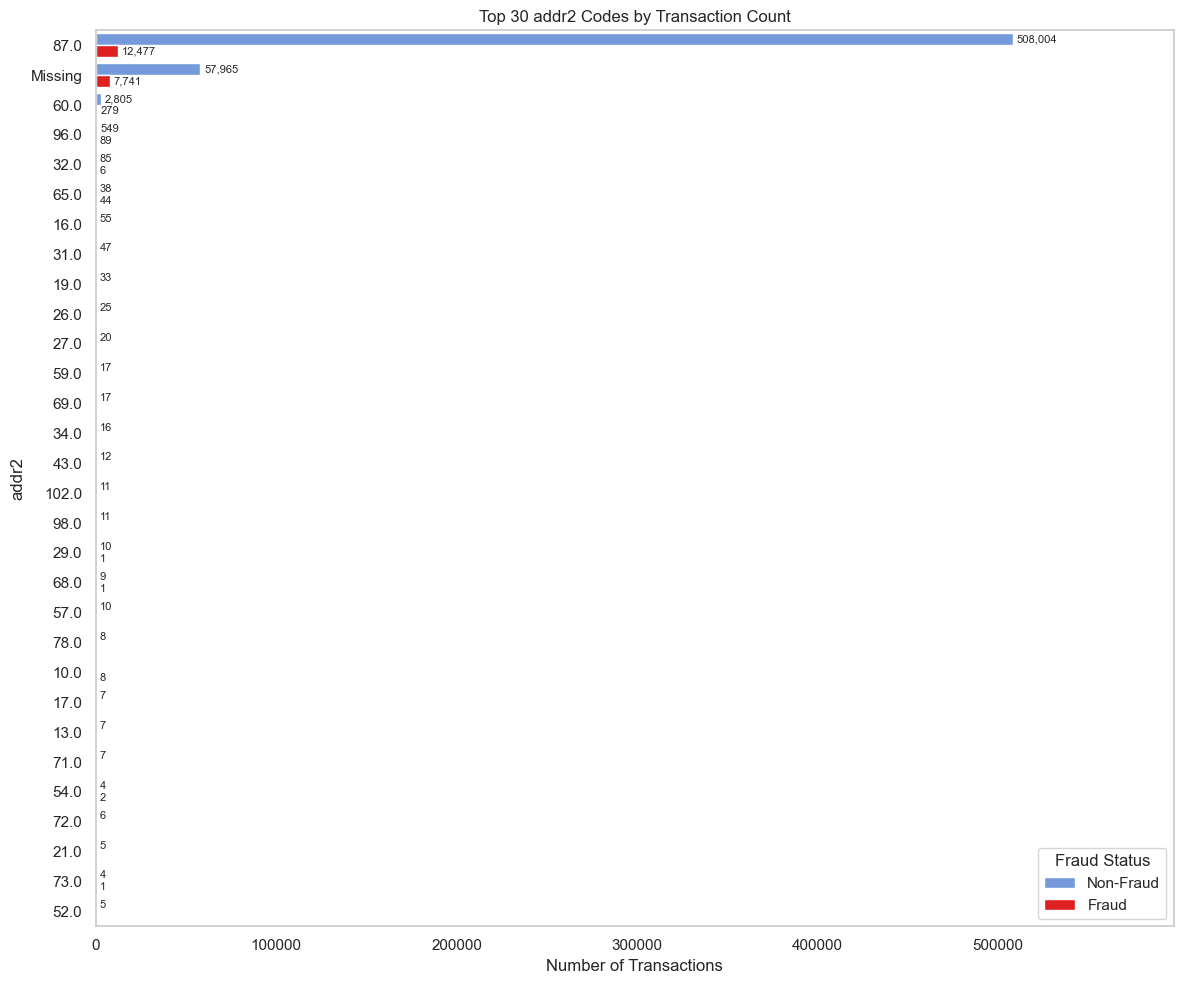

In [39]:
for feature in ["addr1", "addr2"]:

    top_values = df[feature].value_counts().head(30).index
    plot_data = df[df[feature].isin(top_values)]

    plt.figure(figsize=(12, 10))
    ax = sns.countplot(data=plot_data, y=feature, hue="Fraud Status", order=top_values, palette=colors)
    # Add transaction numbers to bars
    for container in ax.containers:
        labels = [
            f"{int(value):,}" if value > 0 else ""
            for value in container.datavalues
        ]
        ax.bar_label(container, labels=labels, padding=3,fontsize=8)
    ax.set_title(f"Top 30 {feature} Codes by Transaction Count")
    ax.set_xlabel("Number of Transactions")
    ax.set_ylabel(feature)
    ax.grid(False)
    ax.set_xlim(right=ax.get_xlim()[1] * 1.12) # Extra space for labels
    plt.tight_layout()
    plt.show()

The transaction distribution was highly concentrated in a small number of address codes. For addr1, the missing category had the highest number of transactions, followed by codes 299, 325, 204 and 264. Most common addr1 codes had considerably more non-fraudulent than fraudulent transactions. 

For addr2, code 87 strongly dominated the dataset, with approximately 508,004 non-fraudulent and 12,477 fraudulent transactions. Its fraud rate was about 2.40%. Missing addr2 values formed the second-largest category and again showed a higher fraud proportion of approximately 11.78%. Most other addr2 codes contained very few transactions, so their fraud proportions may be unreliable.

These results suggest that address codes and missing address information may help distinguish fraudulent transactions.


# M1-M9

In [40]:
m_features = [f"M{i}" for i in range(1, 10)]
df[m_features].isnull().sum()

M1    271100
M2    271100
M3    271100
M4    281444
M5    350482
M6    169360
M7    346265
M8    346252
M9    346252
dtype: int64

In [41]:
df[m_features] = (df[m_features].astype("string").fillna("Missing"))

In [42]:
df[m_features].isnull().sum()

M1    0
M2    0
M3    0
M4    0
M5    0
M6    0
M7    0
M8    0
M9    0
dtype: int64

In [43]:
for feature in m_features:
    print( df[feature].value_counts(dropna=False))

M1
T          319415
Missing    271100
F              25
Name: count, dtype: Int64
M2
T          285468
Missing    271100
F           33972
Name: count, dtype: Int64
M3
Missing    271100
T          251731
F           67709
Name: count, dtype: Int64
M4
Missing    281444
M0         196405
M2          59865
M1          52826
Name: count, dtype: Int64
M5
Missing    350482
F          132491
T          107567
Name: count, dtype: Int64
M6
F          227856
T          193324
Missing    169360
Name: count, dtype: Int64
M7
Missing    346265
F          211374
T           32901
Name: count, dtype: Int64
M8
Missing    346252
F          155251
T           89037
Name: count, dtype: Int64
M9
Missing    346252
T          205656
F           38632
Name: count, dtype: Int64


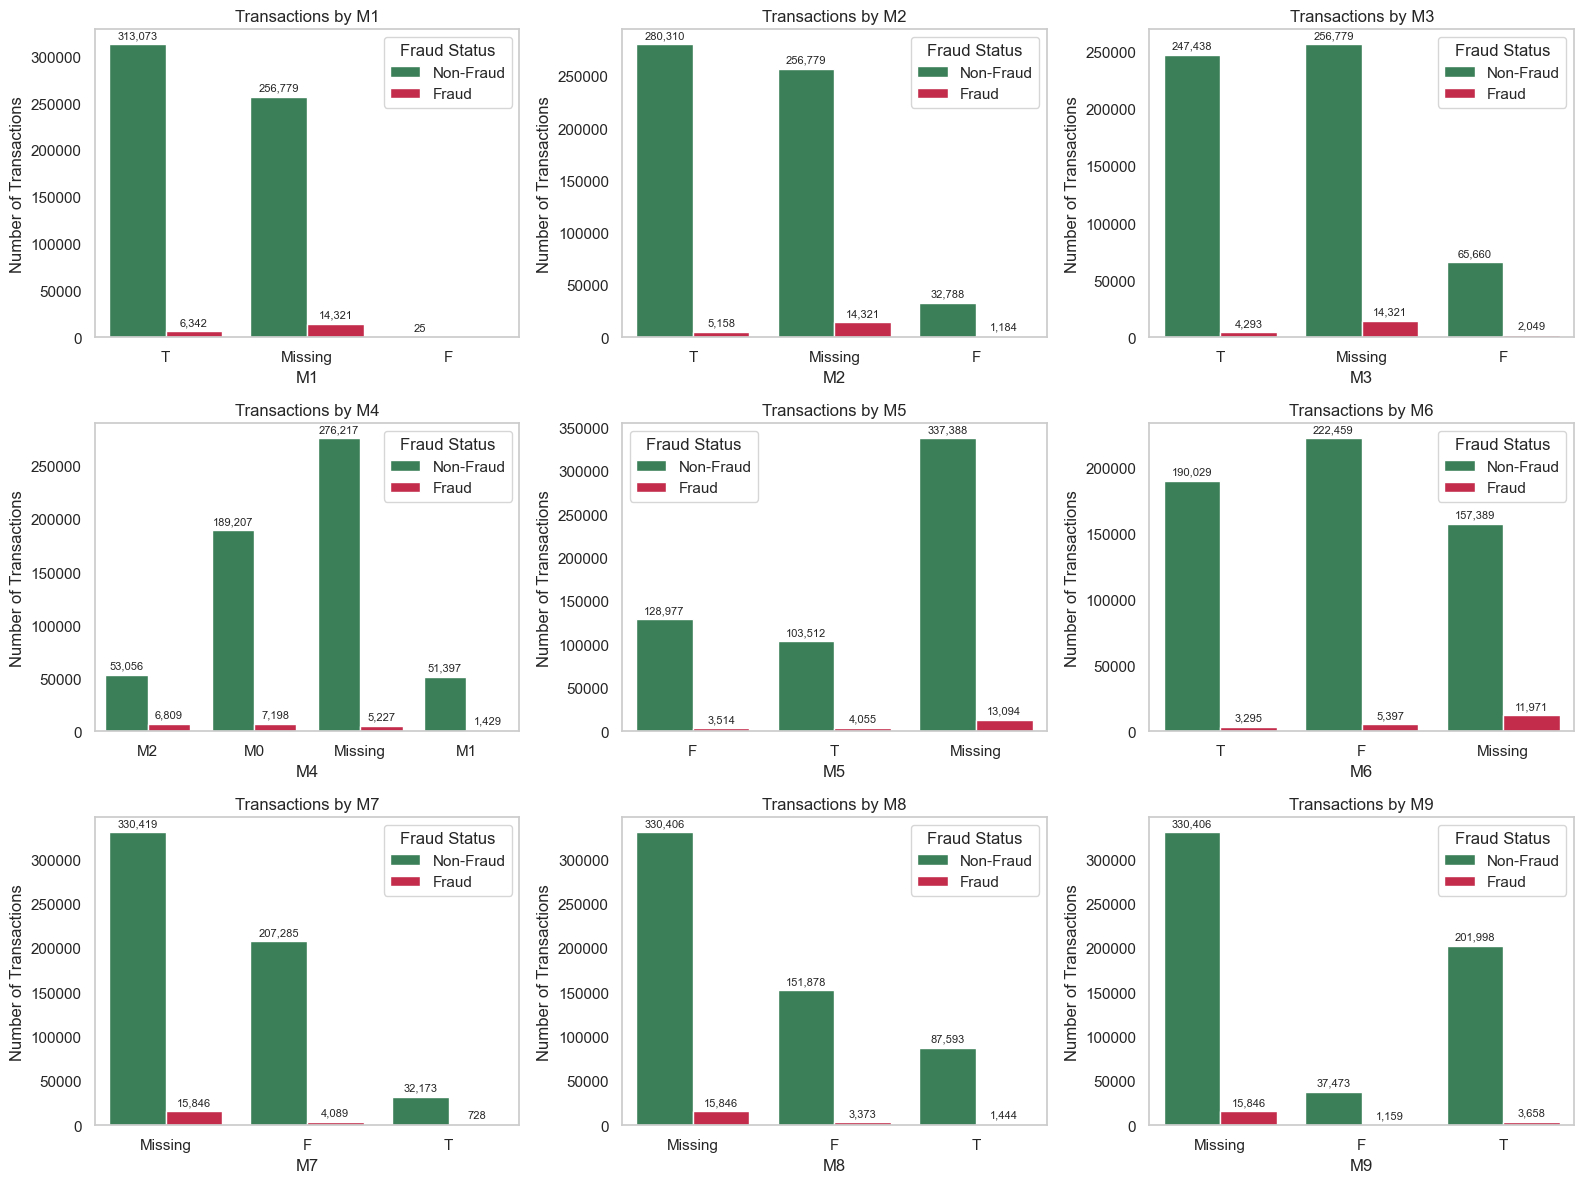

In [44]:
m_features = [f"M{i}" for i in range(1, 10)]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
colors = {"Non-Fraud": "seagreen", "Fraud": "crimson"}
for feature, ax in zip(m_features, axes):
    sns.countplot(data=df, x=feature, hue="Fraud Status", palette=colors, ax=ax)
    for container in ax.containers:
        labels = [
            f"{int(value):,}" if value > 0 else ""
            for value in container.datavalues
        ]
        ax.bar_label(container, labels=labels, padding=3, fontsize=8)
    ax.set_title(f"Transactions by {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Number of Transactions")
    ax.grid(False)
plt.tight_layout()
plt.show()

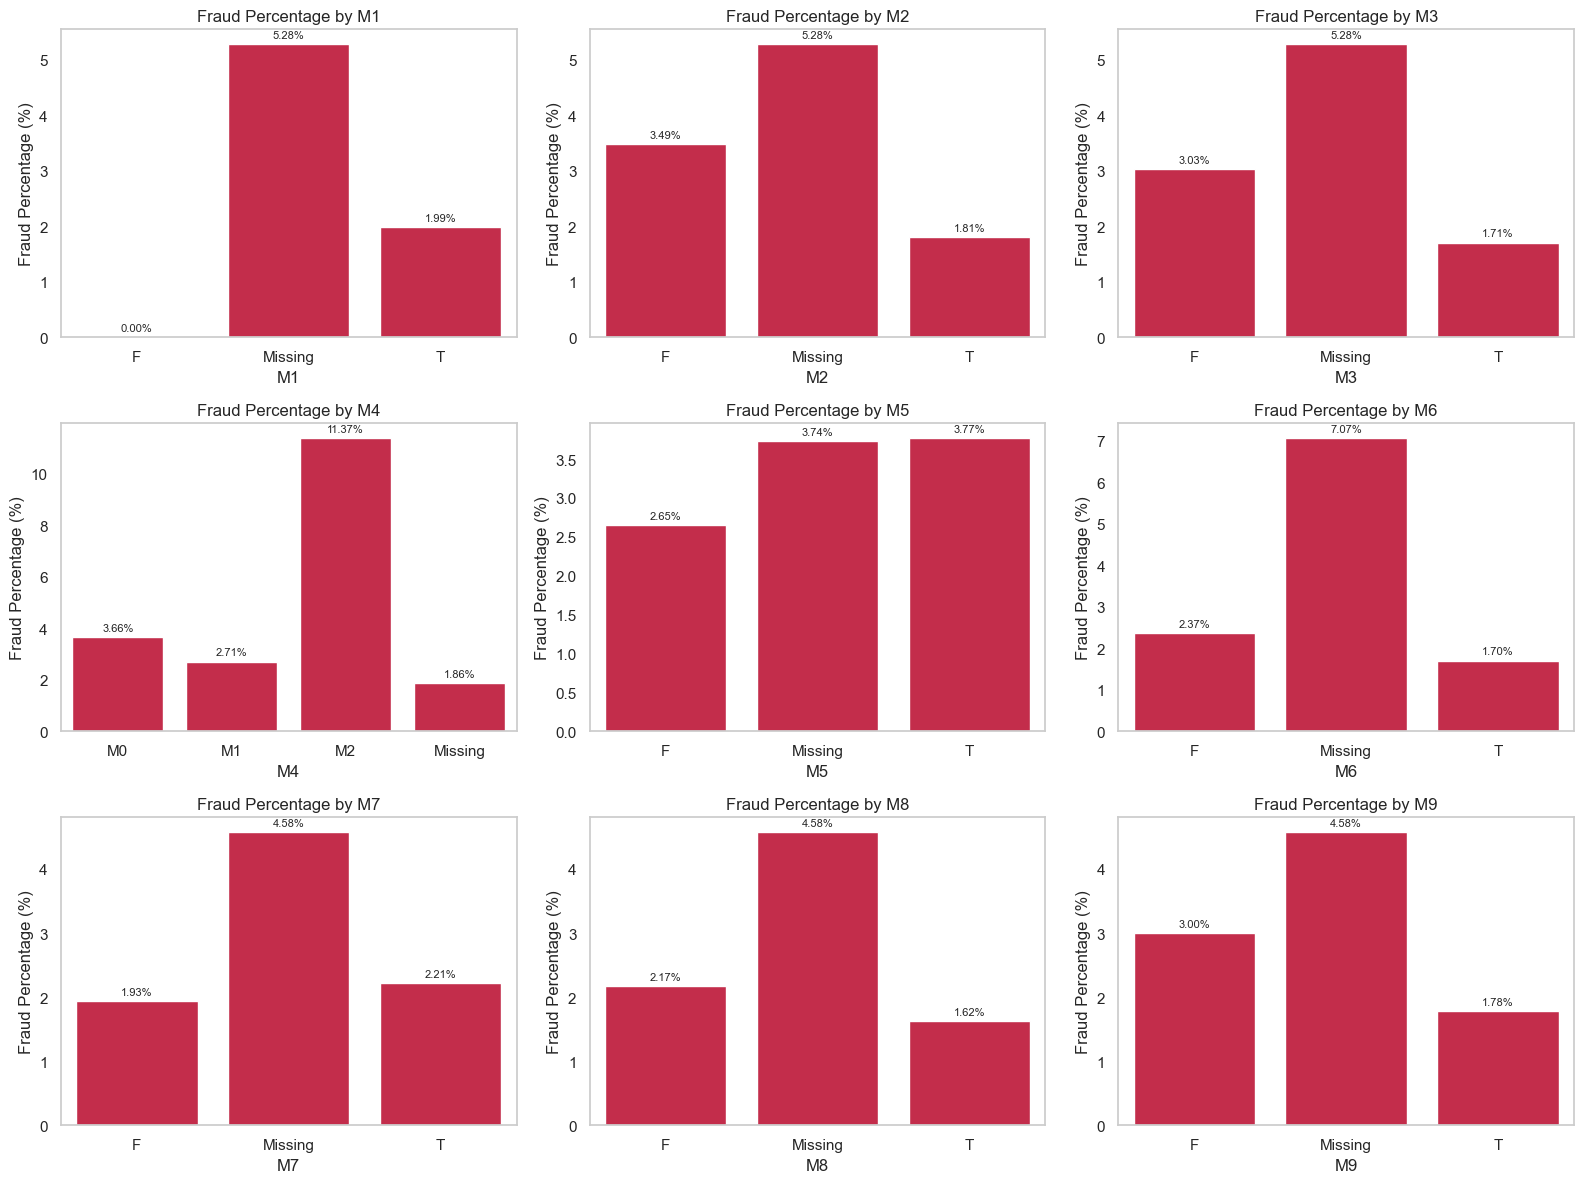

In [45]:
m_features = [f"M{i}" for i in range(1, 10)]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()
for feature, ax in zip(m_features, axes):
    fraud_rate = (df.groupby(feature)["isFraud"].mean().mul(100).reset_index(name="Fraud Percentage"))
    sns.barplot(data=fraud_rate, x=feature, y="Fraud Percentage", color="crimson", ax=ax)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f%%", padding=3, fontsize=8)
    ax.set_title(f"Fraud Percentage by {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Fraud Percentage (%)")
    ax.grid(False)
plt.tight_layout()
plt.show()

The fraud percentage varied across the matching features M1–M9. The strongest difference was observed in M4, where category M2 had the highest fraud rate at 11.37%. For M6, missing values also showed a relatively high fraud rate of 7.07%.

Missing values had higher fraud percentages in M7, M8 and M9, each at approximately 4.58%, compared with their T and F categories. For M5, the fraud rates for T and missing values were similar, at 3.77% and 3.74%.

Overall, the results suggest that both the matching categories and missing-value patterns may be useful indicators for fraud detection. However, these relationships show association only and do not mean that a particular category directly causes fraud.

# DeviceType

In [46]:
# Check missing values
print(df["DeviceType"].isnull().sum())

449730


In [47]:
# Replace missing values
df["DeviceType"] = (df["DeviceType"].astype("string").fillna("Missing"))

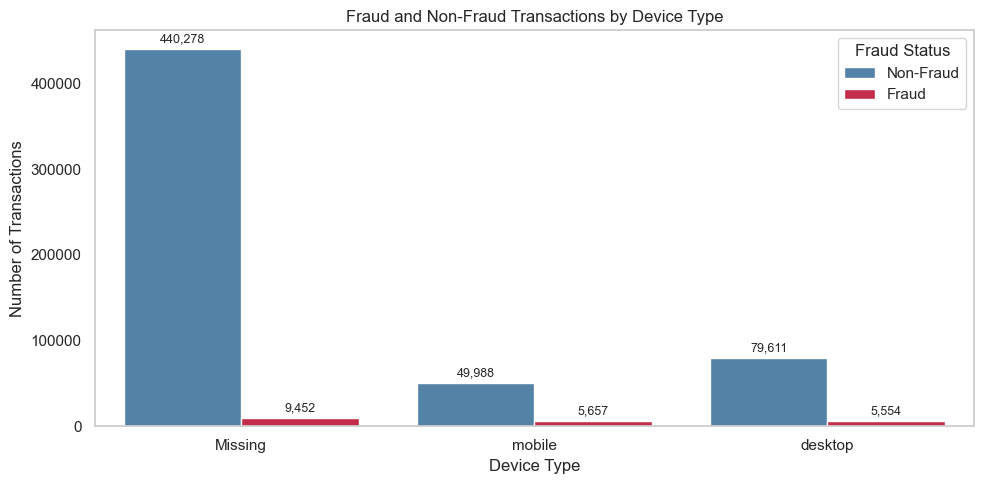

In [48]:
colors = {"Non-Fraud": "steelblue", "Fraud": "crimson"}
plt.figure(figsize=(10, 5))
ax = sns.countplot(data=df, x="DeviceType", hue="Fraud Status", palette=colors)
for container in ax.containers: 
    labels = [
        f"{int(value):,}" if value > 0 else ""
        for value in container.datavalues
    ]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)
ax.set_title("Fraud and Non-Fraud Transactions by Device Type")
ax.set_xlabel("Device Type")
ax.set_ylabel("Number of Transactions")
ax.grid(False)
plt.tight_layout()
plt.show()

The DeviceType distribution was dominated by missing values, with 440,278 non-fraudulent and 9,452 fraudulent transactions. 

 # DeviceInfo

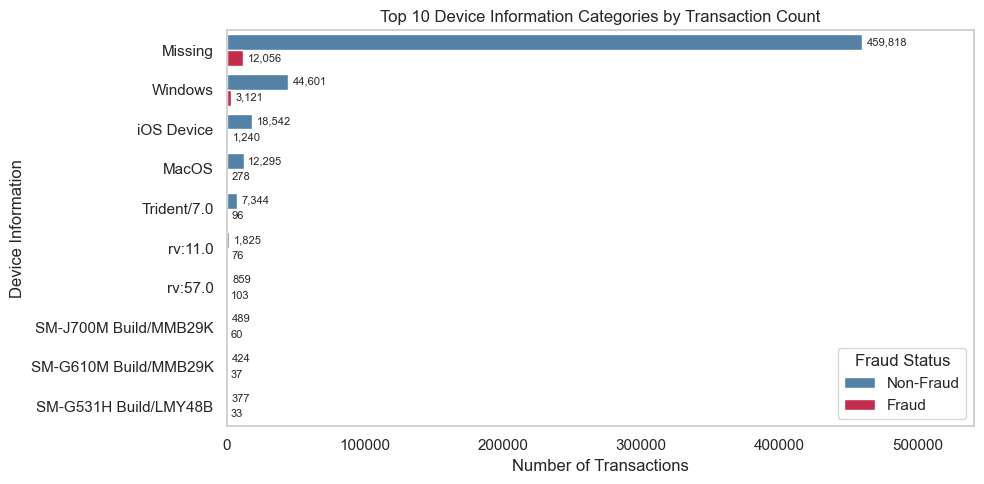

In [49]:
# Replace missing DeviceInfo values
df["DeviceInfo"] = (df["DeviceInfo"].astype("string").fillna("Missing"))

# Select the 10 most common device-information categories
top_values = df["DeviceInfo"].value_counts().head(10).index
plot_data = df[df["DeviceInfo"].isin(top_values)]

plt.figure(figsize=(10, 5))
ax = sns.countplot(data=plot_data, y="DeviceInfo", hue="Fraud Status", order=top_values, palette=colors)
for container in ax.containers: 
    labels = [
        f"{int(value):,}" if value > 0 else ""
        for value in container.datavalues
    ]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)
ax.set_title("Top 10 Device Information Categories by Transaction Count")
ax.set_xlabel("Number of Transactions")
ax.set_ylabel("Device Information")
ax.grid(False)
ax.set_xlim(right=ax.get_xlim()[1] * 1.12)
plt.tight_layout()
plt.show()

The DeviceInfo feature was dominated by missing values, with 459,818 non-fraudulent and 12,056 fraudulent transactions. Windows had the highest number of transactions, followed by iOS Device and MacOS. Fraudulent transactions were much fewer than non-fraudulent transactions in every category. Some less common device categories showed a higher fraud proportion, but they contained very few transactions, so these rates may not be reliable. Overall, DeviceInfo may provide useful information for fraud detection, although its large number of missing values and many rare categories limit its interpretation.

# Id 12- 38

In [50]:
id_features = [f"id_{i:02d}" for i in range(12, 39)]
id_missing = pd.DataFrame({
    "Missing Count": df[id_features].isnull().sum(),
    "Missing Percentage": (
        df[id_features].isnull().mean() * 100
    ).round(2)
})

display(id_missing)

,Missing Count,Missing Percentage
id_12,446307,75.58
id_13,463220,78.44
id_14,510496,86.45
id_15,449555,76.13
id_16,461200,78.10
id_17,451171,76.40
id_18,545427,92.36
id_19,451222,76.41
id_20,451279,76.42
id_21,585381,99.13


The categorical identity features id_12 to id_38 contained very high levels of missing data. All features had more than 75% missing values. The highest missingness was found in id_21 to id_27, where approximately 99% of values were missing. id_18 also had 92.36% missing values, while id_14, id_30, id_32, id_33 and id_34 had around 86%–88% missingness. The remaining features generally had missing percentages between 75% and 78%. This confirms that many identity-related features were sparsely bserved, partly because identity-table records were available for only a subset of transactions.

# Correlation

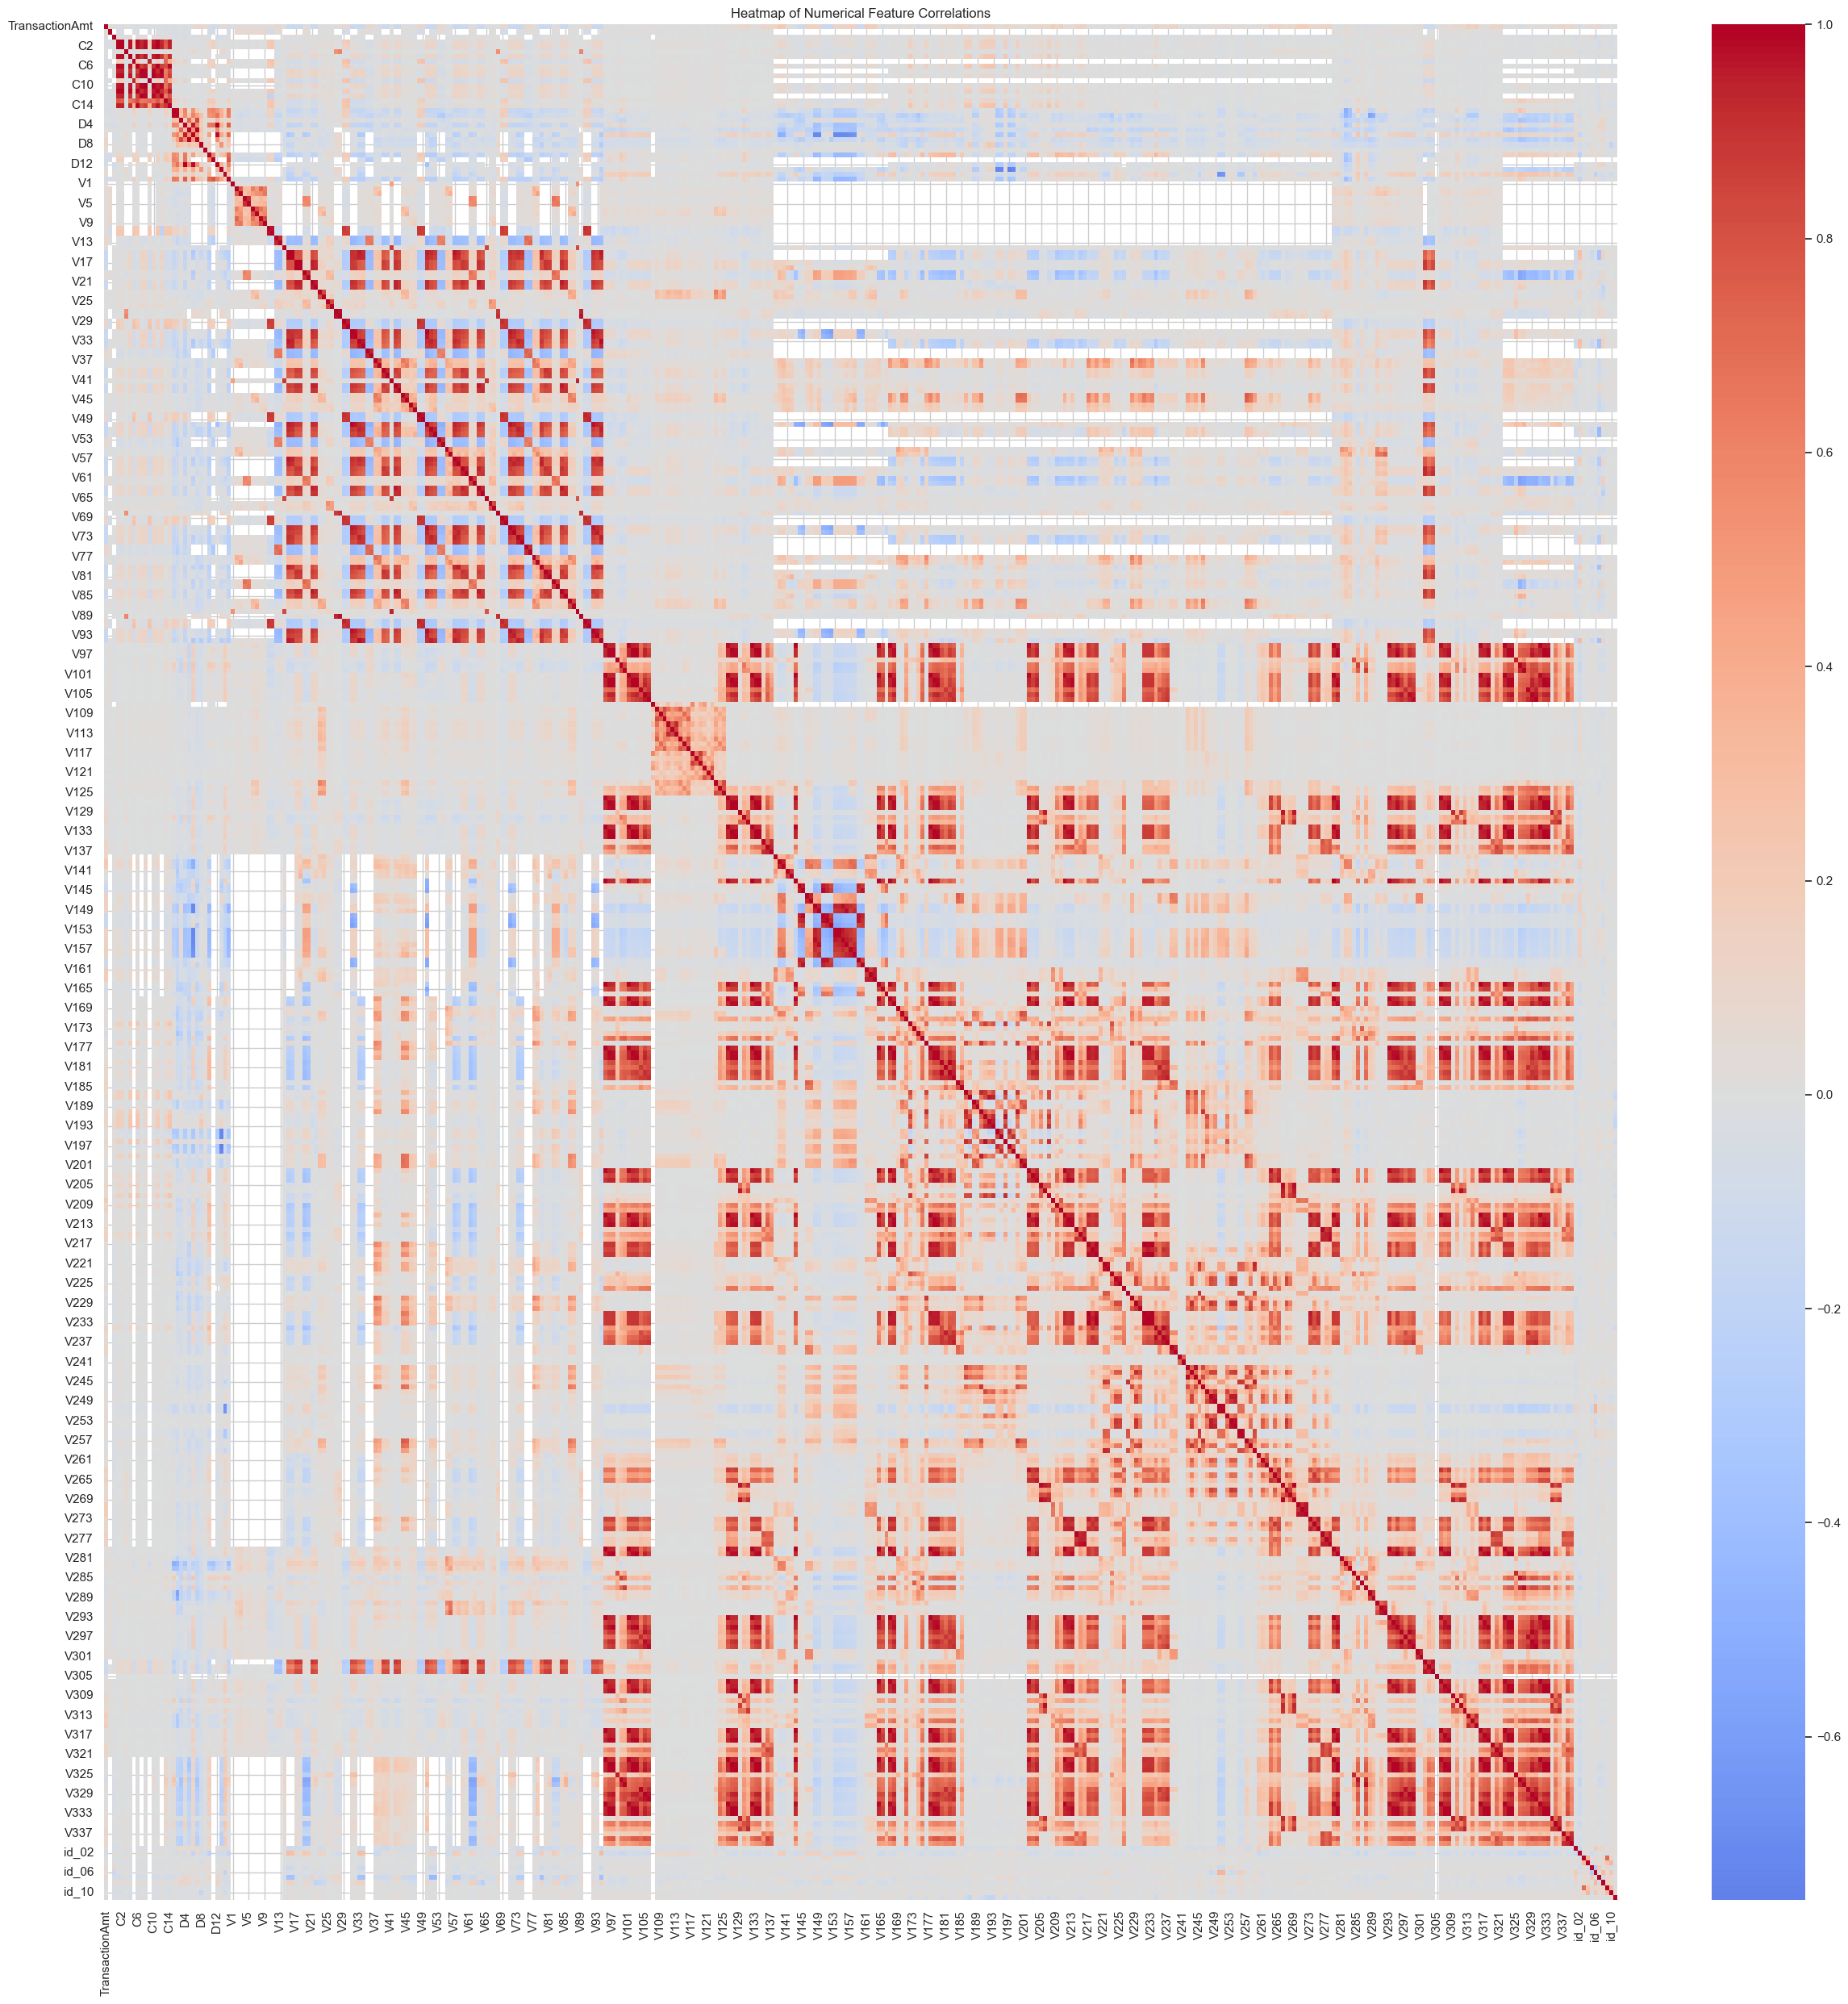

In [51]:
correlation_df = df.copy()
categorical_features = (["ProductCD"]+ [f"card{i}" for i in range(1, 7)] + ["addr1", "addr2", "P_emaildomain", "R_emaildomain"] + [f"M{i}" for i in range(1, 10)] + ["DeviceType", "DeviceInfo"]+ [f"id_{i:02d}" for i in range(12, 39)])
other_columns_to_drop = ["isFraud", "has_identity", "TransactionID", "TransactionDT", "TransactionDay", "TransactionWeek", "RelativeWeekday", "RelativeHour", "Fraud Status"]
correlation_df.drop(columns=categorical_features + other_columns_to_drop, errors="ignore", inplace=True)
correlation_matrix = correlation_df.corr(numeric_only=True)

plt.figure(figsize=(25, 25))
sns.heatmap(correlation_matrix, cmap="coolwarm",center=0)
plt.title("Heatmap of Numerical Feature Correlations")
plt.tight_layout()
plt.show()

The correlation heatmap shows several groups of strongly correlated numerical variables. The clearest correlation patterns occur among the anonymised V features, where multiple red blocks indicate strong positive relationships and some blue areas indicate negative relationships. Several C and D variables also show moderate to strong correlations within their feature groups. This suggests that some numerical features may contain overlapping or redundant information. Most relationships outside these clusters are weak and close to zero. The white areas represent correlations that could not be calculated, mainly because of extensive missing values or insufficient variation in some columns. Since isFraud was excluded, the heatmap represents correlations between predictor variables only.

In [52]:
# Add the target column
pearson_df = correlation_df.copy()
pearson_df["isFraud"] = df["isFraud"]

# Calculate Pearson correlation coefficients with isFraud
pearson_coefficients = (pearson_df.corr(method="pearson", numeric_only=True)["isFraud"].drop("isFraud").sort_values())
display(pearson_coefficients.rename("Pearson Correlation").to_frame())

,Pearson Correlation
D8,-0.142636
D7,-0.127199
id_01,-0.120099
V48,-0.115786
V49,-0.110920
...,...
V201,0.328005
V242,0.360590
V244,0.364129
V246,0.366878


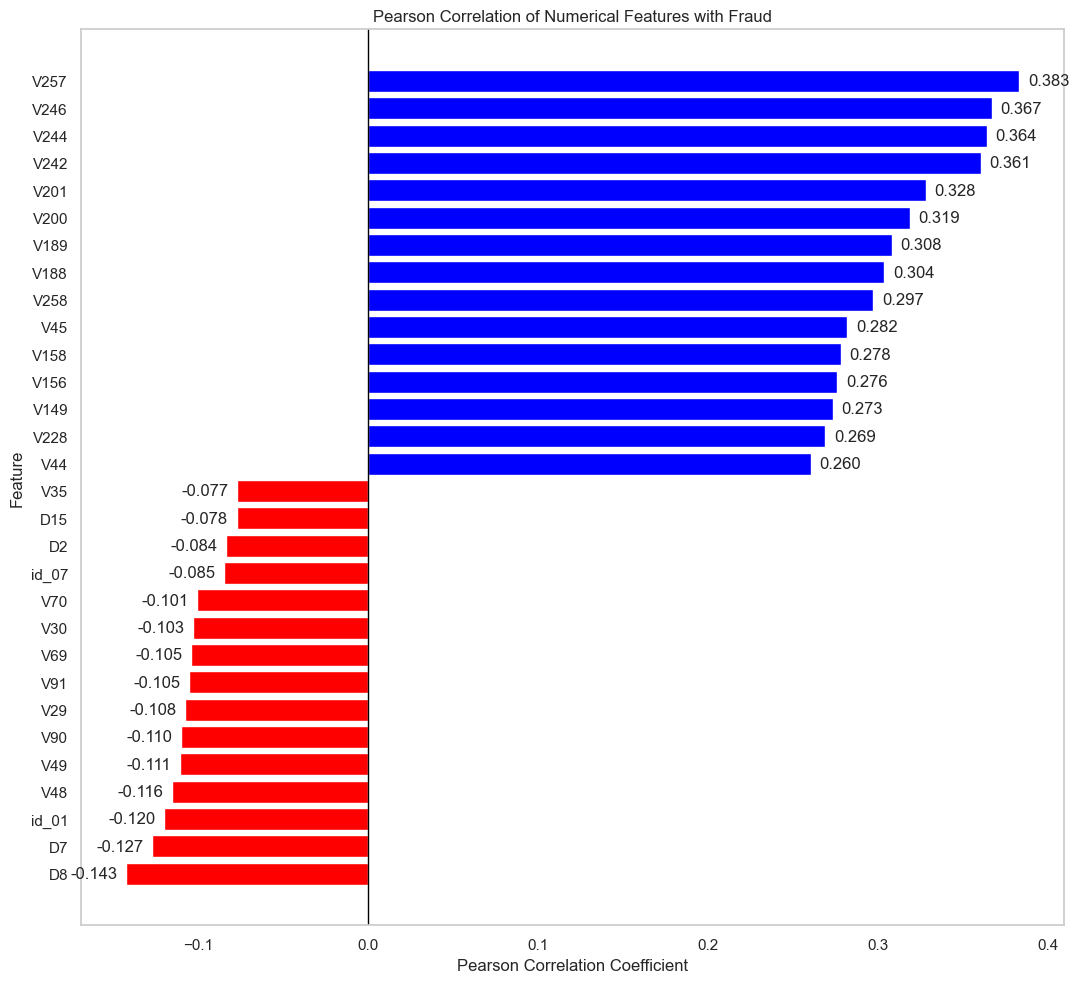

In [53]:
top_positive = pearson_coefficients.nlargest(15)
top_negative = pearson_coefficients.nsmallest(15)
combined_pearson = pd.concat([top_negative, top_positive]).sort_values()
colors = ["red" if value < 0 else "blue" for value in combined_pearson.values]

plt.figure(figsize=(11, 10))
bars = plt.barh(combined_pearson.index, combined_pearson.values, color=colors)
for bar, value in zip(bars, combined_pearson.values):
    x_position = value + 0.005 if value >= 0 else value - 0.005
    alignment = "left" if value >= 0 else "right"

    plt.text(x_position, bar.get_y() + bar.get_height() / 2,f"{value:.3f}", ha=alignment, va="center")
plt.axvline(0, color="black", linewidth=1)
plt.title("Pearson Correlation of Numerical Features with Fraud")
plt.xlabel("Pearson Correlation Coefficient")
plt.ylabel("Feature")
plt.grid(False)
plt.tight_layout()
plt.show()

Pearson correlation was used to examine linear associations between numerical features and the fraud target.

The strongest positive linear association was observed for V257 (r = 0.383), followed by V246 (r = 0.367), V244 (r = 0.364) and V242 (r = 0.361). Higher values of these features were therefore associated with the fraudulent class, although correlation does not imply causation.

The strongest negative associations were observed for D8 (r = -0.143), D7 (r = -0.127) and id_01 (r = -0.120). These associations were weaker in magnitude than the strongest positive correlations.

No numerical feature had an absolute Pearson correlation above 0.40, indicating that no individual numerical feature showed a particularly strong linear relationship with fraud. However, low Pearson correlation does not imply that a feature lacks predictive value because non-linear models may capture more complex relationships and feature interactions.

Because many numerical variables contained missing values, pairwise correlations were calculated using available observations. These coefficients should therefore be interpreted as exploratory associations rather than final measures of feature importance.

# 5. EDA Summary

The exploratory analysis identified several important characteristics of the IEEE-CIS fraud dataset. The target variable was highly imbalanced,
with approximately 3.5% of transactions labelled as fraudulent. Many identity-related features contained substantial missingness, while transaction amounts showed a strongly right-skewed distribution.

Observed fraud rates varied across several categorical variables, although results for rare categories were interpreted cautiously.

Relative temporal patterns were also observed. However, TransactionDT represents elapsed time from an undisclosed reference point, so the derived seven-day and 24-hour cycles cannot be interpreted as actual weekdays or clock hours.

Several numerical features showed moderate linear associations with fraud, while groups of numerical predictors were strongly correlated. These observations informed the subsequent preprocessing and modelling analysis, while all learned preprocessing operations were performed using training data only.